# MATH569 Statistical Learning Final Project
# Modelling Groundwater Nitrate Levels From Land Use Cover

Submission by Warwick Simpson, Student ID: A20662164, Email: wsimpson1@hawk.illinoistech.edu

This project models groundwater nitrate levels in the North Island of New Zealand from land use data, using LASSO, Decision Tree, and Random Forest regressors on 472 well observations. Random Forest on untransformed data performs best ($R^2$ = 0.245), with Short-rotation Cropland and High Producing Exotic Grassland as the strongest positive drivers of nitrate. An addendum demonstrates that adding well depth raises $R^2$ to 0.335, showing the importance of that feature, and that the land use relationships identified remain after controlling for depth.

# Table of Contents
1. [Introduction](#introduction)
    - [Background](#background)
    - [The Question](#the-question)
    - [The Data](#the-data)
    - [The Models](#the-models)
2. [Datasets](#datasets)
3. [Data Preprocessing](#data-Preprocessing)
4. [Data Cleaning](#data-cleaning)
5. [Exploratory Data Analysis](#exploratory-data-analysis)
6. [Feature Grouping](#feature-grouping)
7. [Modelling](#modelling)
    - [LASSO on raw data](#lasso-on-raw-data)
    - [Decision Tree Regressor on raw data](#decision-tree-regressor-on-raw-data)
    - [Random Forest Regressor on raw data](#random-forest-regressor-on-raw-data)
    - [LASSO on log transformed data](#lasso-on-log-transformed-data)
    - [Decision Tree Regressor on log transformed data](#decision-tree-regressor-on-log-transformed-data)
    - [Random Forest Regressor on log transformed data](#random-forest-regressor-on-log-transformed-data)
8. [Summary and Conclusion](#summary-and-conclusion)
9. [Addendum: Inclusion of Well Depth](#addendum-inclusion-of-well-depth)
    - [Loading and Collation of Data](#loading-and-collation-of-data)
    - [Well Depth EDA](#well-depth-eda)
    - [Modelling With and Without Well Depth](#modelling-with-and-without-well-depth)
    - [Well Depth Summary & Conclusions](#well-depth-summary--conclusions)


In [ ]:
# Package Imports

# Standard imports
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import requests

# EDA
from scipy.stats import boxcox

# Modelling
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
import shap

# Geospatial work
import geopandas as gpd
from shapely.geometry import Point
from scipy.spatial import cKDTree


# Introduction
## Background
I currently manage a vegetable growing operation in New Zealand (NZ), growing sweetpotato (known as kumara in NZ). A hot topic in the horticulture industry, particularly in regards to regulations being brought in by both local and national government, is nitrogen leaching. N-leaching comes about from various farmers applying nitrogen (N) fertilisers to their crops, and as N is very water soluble any excess not taken up by the plants can get washed into whatever the local water system is by rain (e.g. down to underground aquifers, or into drains/rivers etc.) where it makes its way to the nearest catchment (i.e. a harbour, lake or similar) and can cause environmental issues.
There are expensive research projects involving lysimeters to measure the amount of leaching from particular crops, and much debate about who should be regulated and how. e.g. levies on fertilisers, limits to fertiliser use, applied to dairy farmers, vegetable growers, orchard growers.


## The Question
Can the nitrate content of groundwater be modelled based on the surrounding land use?

Identifying which land-use types are the most significant predictors of high nitrate levels could be useful to government regulators, and industry advocacy groups to provide direction or defense. Using publicly available data on groundwater wells/bores and land use may provide a cheap and efficient way to get this information.

## The Data
For this project I have combined two datasets. LAWA monitor groundwater quality, including Nitrate Nitrogen, in their many wells (lawa-groundwater-quality-dataset_17oct2025.xlsx downloaded from https://www.lawa.org.nz/explore-data/groundwater-quality and filtered in Excel for North Island wells and Nitrogen levels and saved as lawa_ground_water_nitrogen_north_island.csv) and LRIS maintain a database of Land Cover (https://lris.scinfo.org.nz/layer/123148-lcdb-v60-land-cover-database-version-60-mainland-new-zealand/services/wfs/), which details how all the land across NZ is used, split into 31 categories such as Short-rotation Cropland, Indigenous Forest, or High Producing Exotic Grassland, from which I downloaded the land cover of the North Island as lcdb-v60-land-cover-database-version-60-mainland-new-zealand.gpkg. This file is not included in the submission as it is ~700MB, if you require it please contact me at wjsimpson@gmail.com. I have included north_island_land_use_matrix.csv which is the dataset derived from that .gpkg file.

I combine these two datasets by using the location data of each well in the wells dataset, and applying a 5km radius circle around each well and matching that up with the Land Cover map so I can get the percentage of each land use in each 5km radius circle around each well.  This gives me 31 features of land use percentages, a target variable of Nitrate level in mg/L, and 472 data points. Because of the relatively large number of features, I will apply some grouping. I've only analysed the data from the North Island, partly because it would be reasonable to expect a difference in effects between the two islands, and the land cover information is quite large, with the North Island data already taking 700MB. 

Initially I was unable to obtain well depth information, and it was apparent this was a key element missing from the model. It's well known that Nitrogen is filtered out of the groundwater as it descends through the ground, so deeper wells will inherently have lower Nitrogen levels. Because of this I've compared the three models without well depth data, however later I was able to obtain depth information for 249 of the 472 wells by downloading .csv files of well & bore data from each regional council's arcgis data portal listed below:
- Northland Regional Council: https://data-nrcgis.opendata.arcgis.com/datasets/NRCGIS::bore-logs/
- Horizons Regional Council: https://data-horizonsrc.opendata.arcgis.com/datasets/1f53ca0f492248e3b0433d20a5630687_0/
- Waikato Regional Council: https://data-waikatolass.opendata.arcgis.com/datasets/219e0a0ef6224b5db25dc61c8f14322f_0/explore
- Greater Wellington Regional Council: https://gwrc-open-data-11-1-gwrc.hub.arcgis.com/datasets/b52e4f95910141118fce229f33928d4c_1/explore
- Bay of Plenty Regional Council: https://data-boprc.opendata.arcgis.com/datasets/BOPRC::well-bore-locations-in-the-bay-of-plenty/about
- Hawke's Bay Regional Council: https://hbrcopendata-hbrc.opendata.arcgis.com/datasets/hbrc::hbrc-wells-database/about

I have not included these .csv files, as they are all several MB each - once again, get in touch if you would like them.

Sadly I couldn't find well & bore data from Auckland Council, Taranaki Regional Council, and Gisborne Regional Council.

With this additional depth data, I've looked at the best model (Random Forest on raw data) on the 249 wells with depth data and compared the models performance with and without the depth data.

## The Models
Given the continuous nature of the target variable in mg/L , we need a regression model (as opposed to a classifier).
The three I will investigate are:
- LASSO: This fits a linear model, which could be appropriate but not certain, and also deals with the multicollinearity inherent in a compositional feature set (i.e. since the features will all sum to 100%) by L1 regularisation. This regularisation is also going to be useful since it's unlikely all 31 features will be useful in the model, so it will drive the coefficients of the unimportant features to 0.
- Decision Tree Regressor: This model will be better suited if the model is non-linear, while maintaining a good degree of interpretability.
- Random Forest Regressor: This is similar to the Decision Tree, but applying an additive model should improve accuracy and reduce overfitting. However this may come at a cost of interpretability.

As we'll see, the target data is heavily right-skewed, and requires realistic values to be positive only. This makes a log transform likely to be useful, so I will investigate results from that as well as the raw/untransformed data.

# Data Preprocessing

In [2]:
## Load source data
# Load the North Island wells and nitrogen data originally downloaded as lawa-groundwater-quality-dataset_17oct2025.xlsx 
# from https://www.lawa.org.nz/explore-data/groundwater-quality before filtering for North Island only in Excel and saving as a .csv
wells_df = pd.read_csv('lawa_groundwater_nitrogen_north_island.csv')

# Convert to GeoDataFrame (GDF)
geometry = [Point(xy) for xy in zip(wells_df.Longitude, wells_df.Latitude)]
wells_gdf = gpd.GeoDataFrame(wells_df, geometry=geometry, crs="EPSG:4326")

wells_gdf = wells_gdf.to_crs("EPSG:2193")

In [3]:
## Note this cell can be skipped if it has been run before, and the feature data can be loaded in from "north_island_land_use_matrix.csv" as in the following cell
# 2. Load the North Island Land Cover downloaded from https://lris.scinfo.org.nz/layer/123148-lcdb-v60-land-cover-database-version-60-mainland-new-zealand/services/wfs/
lcdb = gpd.read_file("Data/lcdb-v60-land-cover-database-version-60-mainland-new-zealand.gpkg")


# 3. Create 5km Buffers for all wells
wells_buffers = wells_gdf.copy()
wells_buffers['geometry'] = wells_buffers.geometry.buffer(5000)

# 4. Spatial Overlay
# Find every intersection between the 5km circles and the land use patches.
intersected = gpd.overlay(lcdb, wells_buffers, how='intersection')

# 5. Calculate Area-weighted Percentages
intersected['area_m2'] = intersected.geometry.area


# Group by Well and Land Cover Name
summary = intersected.groupby(['LAWAWellName', 'Name_2023'])['area_m2'].sum().reset_index()

# Pivot to create Design Matrix (X)
# Rows = Wells, Columns = Land Use Types
design_matrix = summary.pivot(index='LAWAWellName', columns='Name_2023', values='area_m2').fillna(0) 
# using fillna(0) as missing values in the 5km buffer analysis imply no presence of that land cover

# Convert areas to percentages per well
design_matrix = design_matrix.div(design_matrix.sum(axis=1), axis=0) * 100

# Save the final processed matrix
design_matrix.to_csv("north_island_land_use_matrix.csv")

print(design_matrix.head())

Name_2023     Broadleaved Indigenous Hardwoods  Built-up Area (settlement)  \
LAWAWellName                                                                 
106724                                1.524268                    1.223166   
1313                                  0.000000                   24.283579   
1714                                  0.000000                    6.481147   
1719                                  0.000000                    8.398729   
1727                                  0.000000                   22.662714   

Name_2023     Deciduous Hardwoods  Depleted Grassland  Estuarine Open Water  \
LAWAWellName                                                                  
106724                   0.060647                 0.0              0.000000   
1313                     0.294400                 0.0              0.000000   
1714                     2.476319                 0.0              0.000000   
1719                     0.357805                 0.0     

In [4]:
design_matrix = pd.read_csv("north_island_land_use_matrix.csv",index_col='LAWAWellName') # to load from the saved csv to save having to re-process

# Data Cleaning

In [5]:
X = design_matrix
y = wells_df[['LAWAWellName','State']]
y = y.set_index('LAWAWellName')

# Check that all wells are common, between X and y and remove any that aren't
common_wells = X.index.intersection(y.index)

X = X.loc[common_wells]
y = y.loc[common_wells]

In [6]:
# Cleaning - check for NAs
print('NAs in X: ', X.isna().sum(axis = 0).sum())
print('NAs in y: ', y.isna().sum(axis = 0).sum())

# both 0, so no NAs to remove

NAs in X:  0
NAs in y:  0


In [7]:
# Check for Land Use Types that have 0% for all wells as these can be removed
zero_cols = X.columns[X.max() == 0].tolist()

print(f"Number of columns that are 0 for every single well: {len(zero_cols)}")
# 0 columns to drop

Number of columns that are 0 for every single well: 0


In [8]:
X.describe()

,Broadleaved Indigenous Hardwoods,Built-up Area (settlement),Deciduous Hardwoods,Depleted Grassland,Estuarine Open Water,Exotic Forest,Fernland,Flaxland,Forest - Harvested,Gorse and/or Broom,...,Mixed Exotic Shrubland,"Orchard, Vineyard or Other Perennial Crop",River,Sand and Gravel,Short-rotation Cropland,Sub Alpine Shrubland,Surface Mine or Dump,Tall Tussock Grassland,Transport Infrastructure,Urban Parkland/Open Space
count,472.000000,472.000000,472.000000,472.000000,472.000000,472.000000,472.000000,472.000000,472.000000,472.000000,...,472.000000,472.000000,472.000000,472.000000,472.000000,472.000000,472.000000,472.000000,472.000000,472.000000
mean,2.327255,5.146237,0.771654,0.000032,0.614870,4.389612,0.009061,0.006781,0.825861,0.506072,...,0.076951,6.058410,0.616073,0.211758,5.663588,0.010108,0.111368,0.000523,0.112029,1.124601
std,4.908359,8.920876,0.948731,0.000684,2.888837,6.738705,0.041166,0.046290,1.243873,1.696220,...,0.201754,11.252278,0.787277,0.599922,8.018569,0.208538,0.304870,0.010858,0.347874,1.772243
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.012661,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.087149,0.182106,0.110818,0.000000,0.000000,0.878942,0.000000,0.000000,0.093820,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.049511,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.608790,1.079071,0.410001,0.000000,0.000000,1.675431,0.000000,0.000000,0.385532,0.093741,...,0.000000,0.370459,0.267753,0.000000,1.832115,0.000000,0.000000,0.000000,0.000000,0.378704
75%,2.139476,6.873640,1.035822,0.000000,0.000000,4.889513,0.000000,0.000000,0.977557,0.372038,...,0.053707,4.364515,1.041318,0.047460,7.793817,0.000000,0.074648,0.000000,0.027044,1.390219
max,32.495283,77.857123,5.273534,0.014870,47.317460,50.681698,0.446027,0.458926,10.651386,20.282484,...,1.486559,49.000768,4.198473,5.332182,33.521248,4.527860,2.637935,0.235644,2.540960,12.671000


# Exploratory Data Analysis

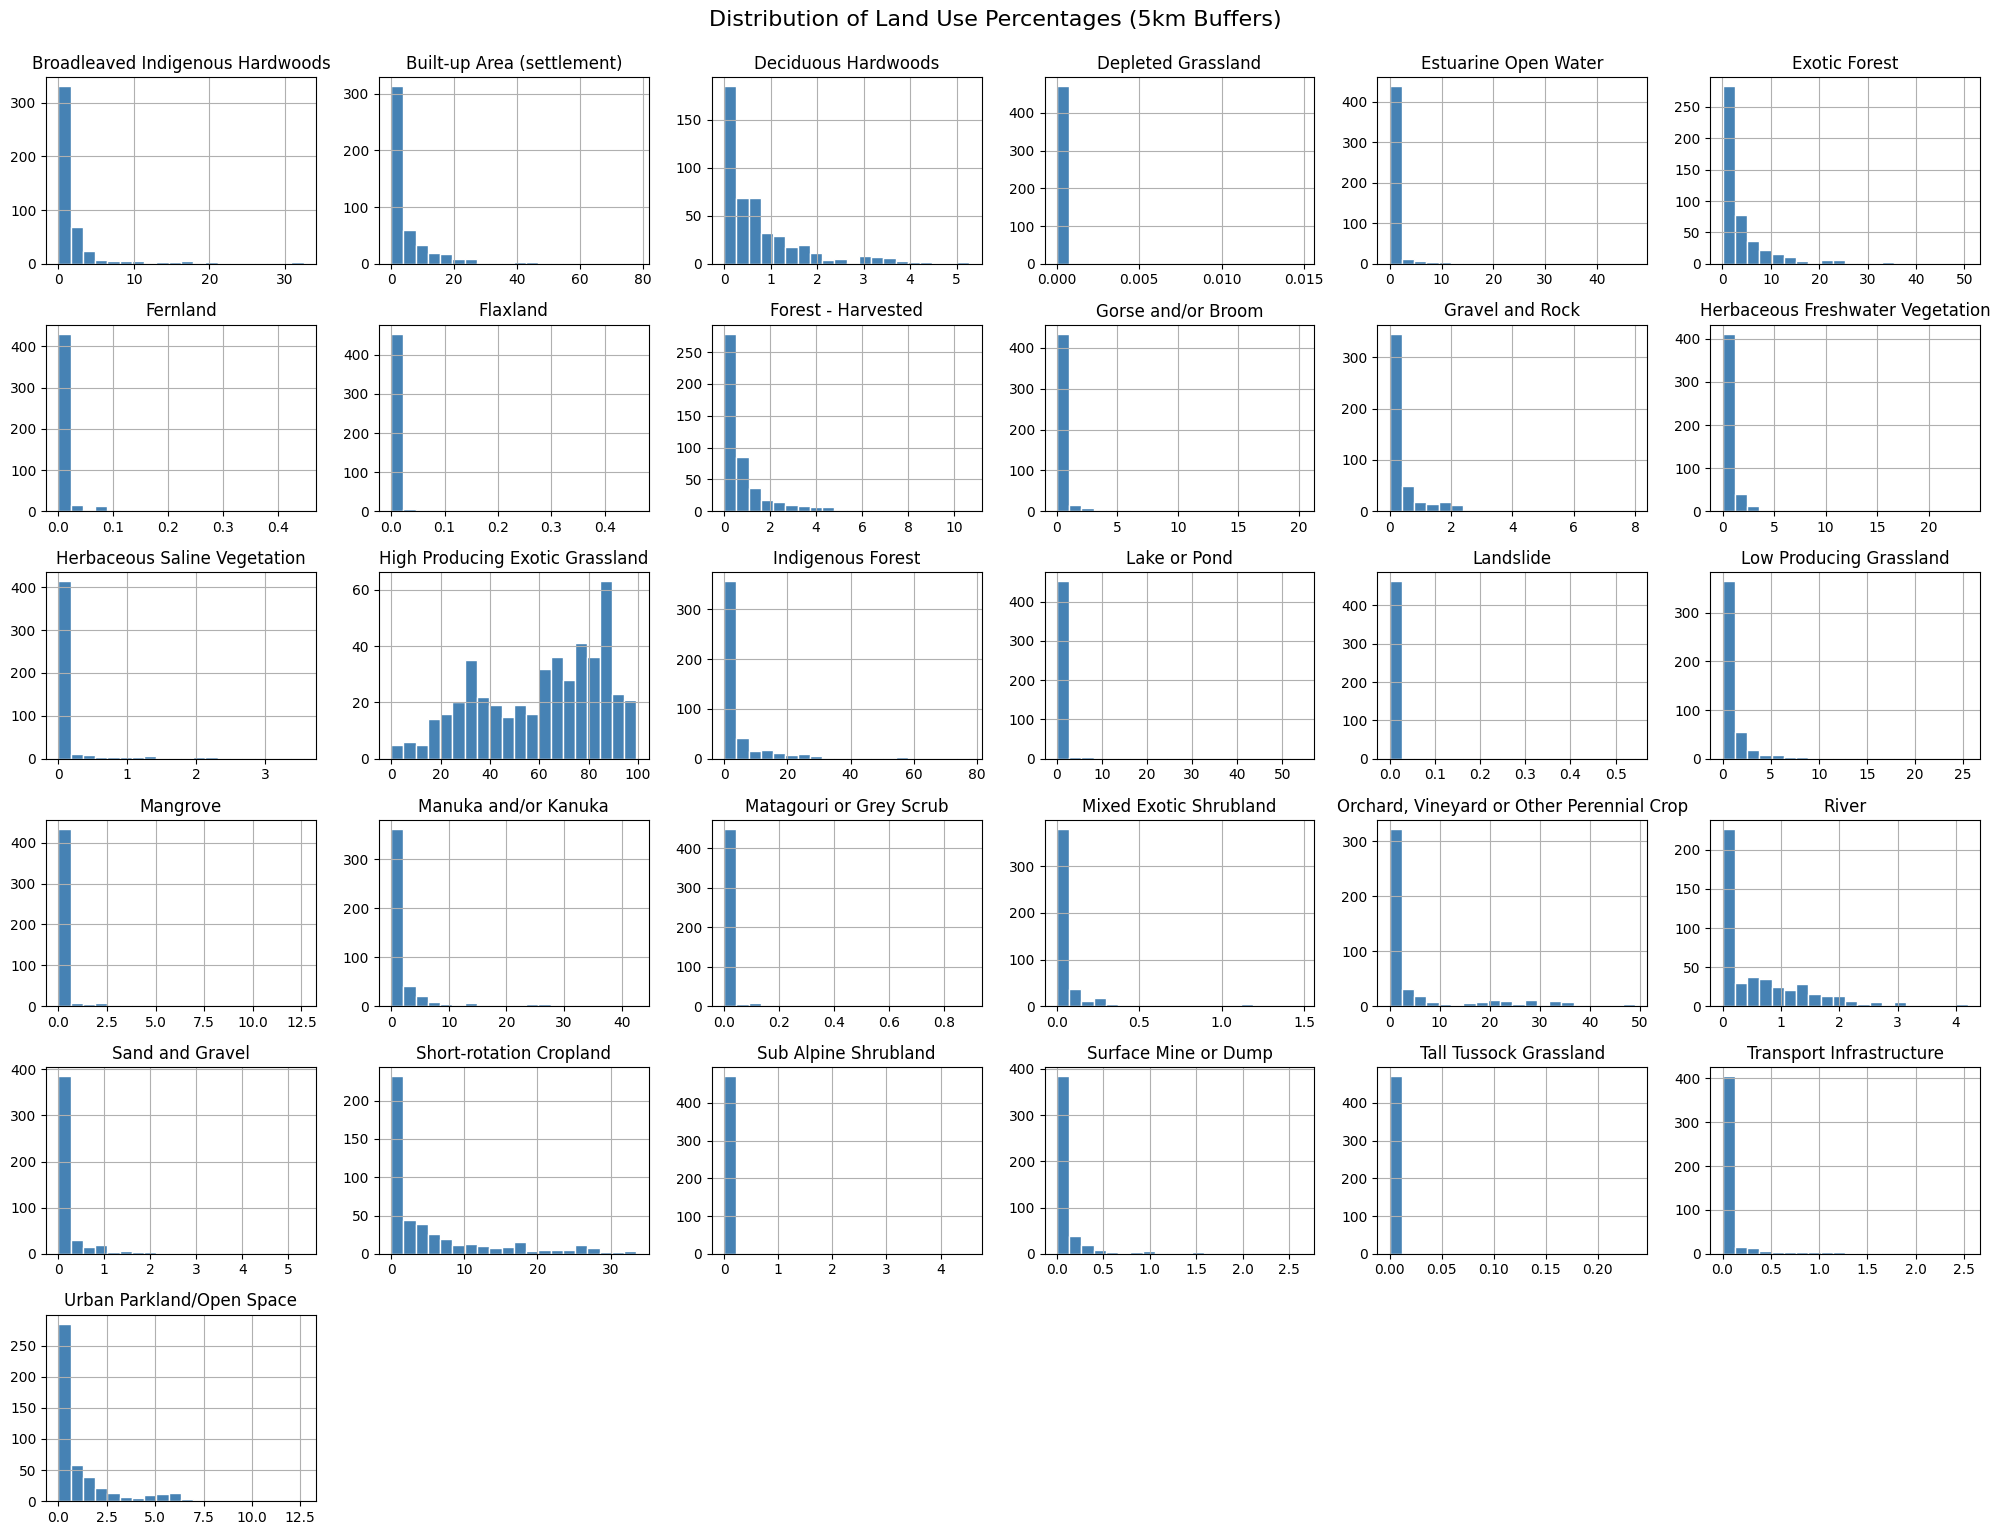

In [9]:

X.hist(bins=20, figsize=(20, 15), color='steelblue', edgecolor='white')
plt.tight_layout()
plt.suptitle("Distribution of Land Use Percentages (5km Buffers)", y=1.02, fontsize=16)

plt.show()

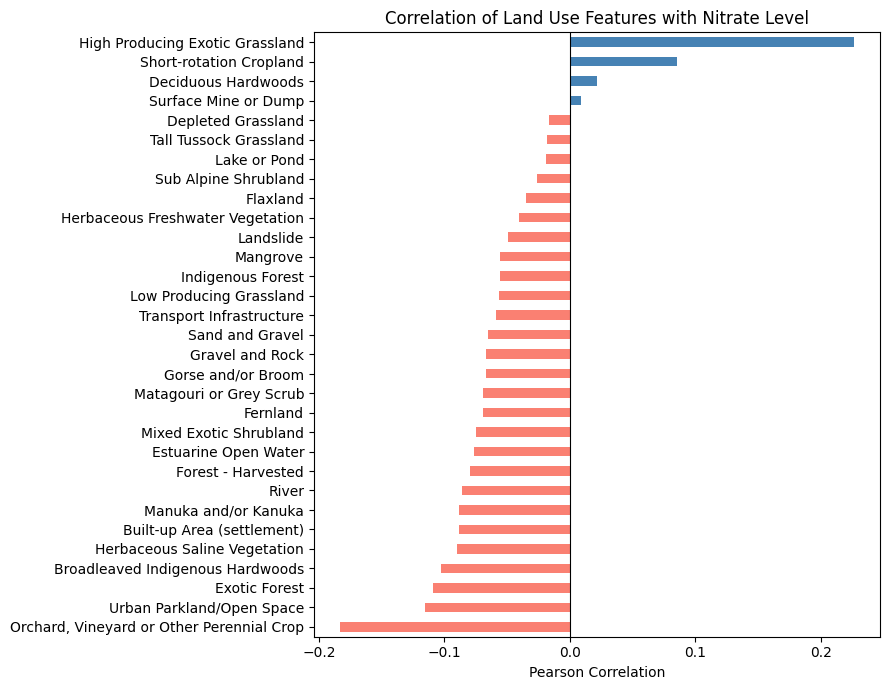

In [10]:
target_corr = X.corrwith(y['State']).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
target_corr.plot(kind='barh', ax=ax, color=(target_corr > 0).map({True: 'steelblue', False: 'salmon'}))
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Correlation of Land Use Features with Nitrate Level")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

From the above histograms, we can see that many of the features have a lot of low values, so grouping them will reduce how sparse the X matrix is and should give a better set of features for the models to work on. In the correlation bar graph above we see that the three key features with strong correlations are 'High Producing Exotic Grassland', 'Short Rotation Cropland' and 'Orchard, Vineyard or Other Perennial Crop', which correspond to three types of commercial farming operations that will be of particular interest, so I'll keep these separate. More about this in [Feature Grouping](#feature-grouping)

Text(0.5, 1.0, 'Target Variable Distribution')

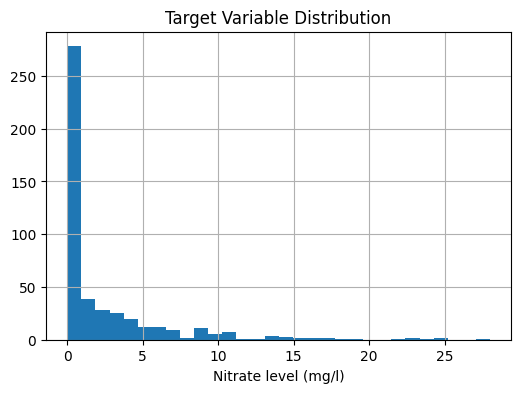

In [11]:
ax = y['State'].hist(bins=30,figsize=(6,4))
ax.set_xlabel('Nitrate level (mg/l)')
ax.set_title('Target Variable Distribution')

In [12]:

# Box-Cox requires strictly positive values - check this first
print(f"Min nitrate value: {y['State'].min()}")  # Must be > 0

y_transformed, lambda_bc = boxcox(y['State'])
print(f"Optimal Box-Cox lambda: {lambda_bc:.4f}")

Min nitrate value: 0.0005
Optimal Box-Cox lambda: 0.0695


The distribution of the target variable (above) shows extremely right-skewed data. The Box-Cox lambda of 0.07 suggests a log-transform is appropriate to improve normality, however this will cause the models to focus more on the smaller values which inherently have a higher proportion of measurement error. Also for the purposes of our modelling we care about the low values less, as environmental concerns are in regard to higher values. 

Essentially, the higher values are not outliers, they're the data points we really care about.

Because of this I look at modelling both the raw data and the log transform and compare.

# Feature Grouping

From cleaning we can see that all 31 features contribute at least a little, however X is quite a sparse matrix. Also, similar types of land use that are split into separate features will tend to have inverse distributions due to the compositional nature of the features - i.e. for each row the sum of the features must add to 100%, so if for example 'Forest - Harvested' increases in %, it would likely correspond to a decrease in 'Exotic Forest' %, when on the longer timescales that affect wells it is the additive combination of these features that is likely to be causing an effect. 

Because of this compositional nature, common dimension reduction techniques like correlation between features or PCA aren't appropriate, as the features that make most sense to combine will likely have somewhat inverse correlation. We also don't want to drop features that have low values, as the sum of several low values may become large enough to cause an effect. Because of this I have applied domain knowledge to form groups to reduce the number of features to 11.

There are three standalone features that are of key interest, as they correspond to commercial farming. These are:
- 'High Producing Exotic Grassland' - this will almost all correspond to Dairy Farming, the largest primary industry in New Zealand which is often blamed for Nitrogen leaching due to effluent and urea application.
- 'Short Rotation Cropland' - this will be things like vegetable crops and arable farming (e.g. grains and maize) which require high fertiliser application.
- 'Orchard, Vineyard or Other Perennial Crop' - another commercial land use, that usually has lower N application and may act more as an N sink rather than source.
We can see from the above correlation bar graph that these are the most strongly correlated with Nitrate Level, so there is a good chance they are significant drivers.

The other groupings are detailed below, and are fairly self explanatory. One group of note is exotic_managed_forest, as this is another commercial land use that may act as an N sink similar to Orchards. The other groups are made up of land uses that don't involve any fertiliser use, so would most likely have a low impact on the model.

In [13]:
# Group definitions
low_intensity_grassland = [
    'Low Producing Grassland',
    'Depleted Grassland',
    'Tall Tussock Grassland'
]

native_scrub_shrubland = [
    'Manuka and/or Kanuka',
    'Matagouri or Grey Scrub',
    'Sub Alpine Shrubland',
    'Mixed Exotic Shrubland',
    'Gorse and/or Broom'
]

native_forest = [
    'Indigenous Forest',
    'Broadleaved Indigenous Hardwoods',
    'Fernland',
    'Flaxland'
]

exotic_managed_forest = [
    'Exotic Forest',
    'Deciduous Hardwoods',
    'Forest - Harvested'
]

urban_builtup = [
    'Built-up Area (settlement)',
    'Transport Infrastructure',
    'Urban Parkland/Open Space',
    'Surface Mine or Dump'
]

freshwater_wetland = [
    'Herbaceous Freshwater Vegetation',
    'Lake or Pond',
    'River'
]

saline_coastal = [
    'Herbaceous Saline Vegetation',
    'Estuarine Open Water',
    'Mangrove'
]

bare_disturbed = [
    'Gravel and Rock',
    'Sand and Gravel',
    'Landslide'
]

# Build the new grouped DataFrame
X_grouped = pd.DataFrame({
    # Intensive agriculture - kept separate (high nitrate risk)
    'High Producing Exotic Grassland':              X['High Producing Exotic Grassland'],
    'Short-rotation Cropland':                      X['Short-rotation Cropland'],
    'Orchard, Vineyard or Other Perennial Crop':    X['Orchard, Vineyard or Other Perennial Crop'],
    # Grouped features
    'Low Intensity Grassland':   X[low_intensity_grassland].sum(axis=1),
    'Native Scrub Shrubland':    X[native_scrub_shrubland].sum(axis=1),
    'Native Forest':             X[native_forest].sum(axis=1),
    'Exotic Managed Forest':     X[exotic_managed_forest].sum(axis=1),
    'Urban Built-up':            X[urban_builtup].sum(axis=1),
    'Freshwater Wetland':        X[freshwater_wetland].sum(axis=1),
    'Saline Coastal':            X[saline_coastal].sum(axis=1),
    'Bare Disturbed Land':       X[bare_disturbed].sum(axis=1),
})

print(X_grouped.shape)        # Should be (n_samples, 11)
print(X_grouped.head())

(472, 11)
              High Producing Exotic Grassland  Short-rotation Cropland  \
LAWAWellName                                                             
106724                              51.353805                 2.291057   
1313                                15.154570                16.818621   
1714                                26.647113                 7.563783   
1719                                25.287071                16.333785   
1727                                19.025431                27.505782   

              Orchard, Vineyard or Other Perennial Crop  \
LAWAWellName                                              
106724                                         0.933648   
1313                                          36.554216   
1714                                          45.558071   
1719                                          43.385218   
1727                                          21.667839   

              Low Intensity Grassland  Native Scrub Shrub

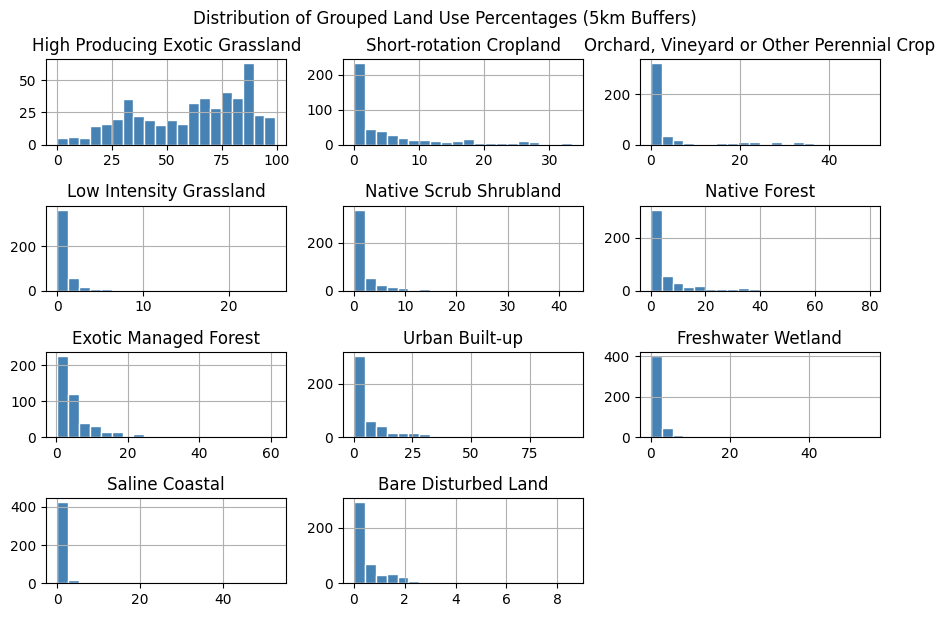

In [14]:
X_grouped.hist(bins=20, figsize=(9, 6), color='steelblue', edgecolor='white')
plt.tight_layout()
plt.suptitle("Distribution of Grouped Land Use Percentages (5km Buffers)", y=1.02)

plt.show()

The above feature histograms show we now have 11 features that operate on roughly similar scales (from checking the x-axis' of the histograms). Given these similar scales I have opted to not scale the features, and maintain easy interpretability.

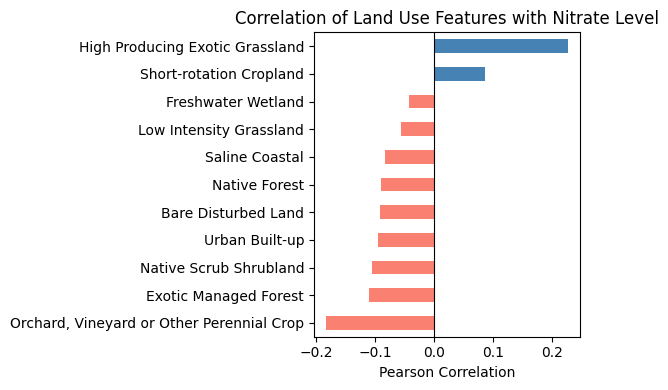

In [15]:
target_corr = X_grouped.corrwith(y['State']).sort_values()

fig, ax = plt.subplots(figsize=(6, 4))
target_corr.plot(kind='barh', ax=ax, color=(target_corr > 0).map({True: 'steelblue', False: 'salmon'}))
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Correlation of Land Use Features with Nitrate Level")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

The above correlation bar graph still shows our three standalone features having the most correlation, and the 8 grouped features which have less correlation.

# Modelling

As detailed in the [Introduction](#introduction) I have chosen to investigate three regression models: LASSO, Decision Tree Regressor and Random Forest Regressor.

## Stratification in train_test_split

Given the extreme skew of the target variable, it's important to apply stratification to make sure values from the tail are in equal proportion across training and test sets. To do this I bin y into 10 categories and use that as the stratification key in train_test_split.

In [16]:
# setup stratification by binning y
bins = pd.qcut(y['State'], q = 10)

# Split the data into training and testing sets, noting that we'll be using cross-validation for hyperparameter tuning
X_train_val, X_test, y_train_val, y_test = train_test_split(X_grouped, y, test_size=0.15, random_state=3, stratify=bins)

## Validation using Cross-validation
While the size of the dataset is moderate at 472 data points, I have opted for k-fold cross-validation as the right-skew of the data means the number of higher value Nitrate data points is limited, so it's useful to use the entire training set across the validation folds. LassoCV has cross-validation built in to determine the optimal $\lambda$, and I use RandomizedSearchCV for hypertuning the two tree type models. In all three cases I use cv=5, i.e. 5 fold cross-validation, where each iteration trains on 4 folds and validates on the 5th, rotating the folds so each fold is used for validation once during the process.
Cross-validation in Lasso works through a variety of $\lambda$, performing cross validation on each one to find the optimal $\lambda$. RandomizedSearchCV works through the selection of hyperparameters for the tree models, picking combinations at random and then performing cross validation on each combination to see how it performs. I've chosen the range of the hyperparameters by starting with a rough guess at a good range, running the code, and if the optimal hyperparameter was at the edge of the range I would increase the range and re-run.

Note the stratified test set (split out using train_test_split above) is kept separate and only used to test how well the model performs to avoid any leakage into hyperparameter selection.

## Metrics
To evaluate the models I've used $R^2$ to evaluate the variance explained by the model, and root mean squared error (RMSE) and mean absolute error (MAE) to evaluate the fit. I've used both because while RMSE is standard, it does emphasise larger errors, and MAE may be a fairer metric, especially when we're comparing models of log transformed data.

## LASSO on raw data

In [17]:
# LassoCV attempt with grouped features
lasso_model = LassoCV(cv=5).fit(X_train_val, y_train_val.values.ravel())

lasso_rmse = np.round(root_mean_squared_error(y_test, lasso_model.predict(X_test)),2)
print("RMSE on test: ", lasso_rmse)
lasso_mae = np.round(mean_absolute_error(y_test, lasso_model.predict(X_test)),2)
print("MAE on test", lasso_mae)
lasso_r2 = np.round(r2_score(y_test, lasso_model.predict(X_test)),3)
print("R\u00B2 on test: ", lasso_r2)

coef_df = pd.DataFrame({
    'Feature':     X_train_val.columns,
    'Coefficient': lasso_model.coef_,
}).sort_values('Coefficient', key=abs, ascending=False)

print(coef_df.to_string(index=False))

RMSE on test:  3.3
MAE on test 2.56
R² on test:  0.187
                                  Feature  Coefficient
                  Short-rotation Cropland     0.159737
Orchard, Vineyard or Other Perennial Crop    -0.108426
          High Producing Exotic Grassland     0.029575
                    Exotic Managed Forest    -0.017462
                  Low Intensity Grassland    -0.000000
                   Native Scrub Shrubland    -0.000000
                            Native Forest     0.000000
                           Urban Built-up     0.000000
                       Freshwater Wetland    -0.000000
                           Saline Coastal    -0.000000
                      Bare Disturbed Land    -0.000000


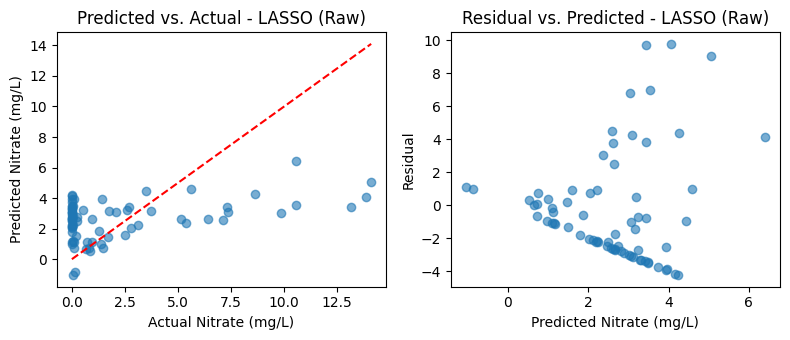

In [18]:
# Generate predictions using lasso model
y_pred = lasso_model.predict(X_test)

fig, [ax1, ax2] = plt.subplots(1,2,figsize=(8, 3.5))
ax1.scatter(y_test, y_pred, alpha=0.6)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax1.set_xlabel("Actual Nitrate (mg/L)")
ax1.set_ylabel("Predicted Nitrate (mg/L)")
ax1.set_title("Predicted vs. Actual - LASSO (Raw)")
ax2.scatter(y_pred, y_test['State']-y_pred, alpha=0.6)
ax2.set_xlabel("Predicted Nitrate (mg/L)")
ax2.set_ylabel("Residual")
ax2.set_title("Residual vs. Predicted - LASSO (Raw)")
plt.tight_layout()
plt.show()

                                             coef  ci_low  ci_high  \
Short-rotation Cropland                    0.1733  0.0482   0.2839   
High Producing Exotic Grassland            0.0372  0.0172   0.0638   
Native Forest                              0.0100 -0.0004   0.0413   
Urban Built-up                             0.0090 -0.0086   0.0421   
Native Scrub Shrubland                     0.0042 -0.0281   0.0712   
Saline Coastal                            -0.0014 -0.0386   0.0237   
Low Intensity Grassland                   -0.0051 -0.0907   0.0719   
Freshwater Wetland                        -0.0083 -0.0715   0.0498   
Exotic Managed Forest                     -0.0161 -0.0515   0.0000   
Bare Disturbed Land                       -0.0565 -0.3425   0.0000   
Orchard, Vineyard or Other Perennial Crop -0.1070 -0.1786  -0.0358   

                                           pct_nonzero  
Short-rotation Cropland                           98.8  
High Producing Exotic Grassland              

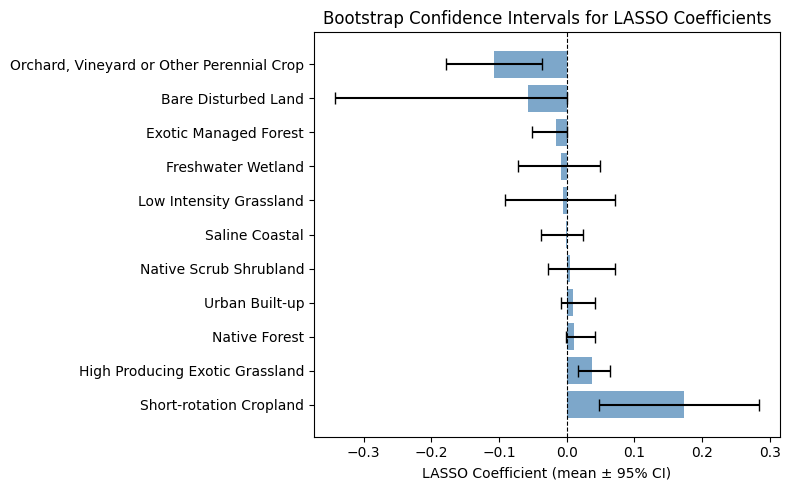

In [19]:
# Using Bootstrap to find confidence intervals of coefficients

N_BOOTSTRAP = 1000

coef_samples = np.zeros((N_BOOTSTRAP, X_grouped.shape[1]))

for i in range(N_BOOTSTRAP):
    # Resample with replacement
    idx = np.random.choice(len(X_grouped), size=len(X_grouped), replace=True)
    X_boot = X_grouped.iloc[idx]
    y_boot = y.iloc[idx].values.ravel()
    
    # Refit LassoCV on bootstrap sample
    lasso_boot = LassoCV(cv=5, random_state=3, max_iter=10000)
    lasso_boot.fit(X_boot, y_boot)
    coef_samples[i, :] = lasso_boot.coef_

# Summarise
coef_df = pd.DataFrame(coef_samples, columns=X_grouped.columns)
summary = pd.DataFrame({
    "coef":    coef_df.mean(),
    "ci_low":  coef_df.quantile(0.025),
    "ci_high": coef_df.quantile(0.975),
    "pct_nonzero": (coef_df != 0).mean() * 100  # % of bootstrap runs where coef != 0
}).sort_values("coef", ascending=False)

print(summary.round(4))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
y_pos = range(len(summary))
ax.barh(y_pos, summary["coef"], xerr=[
    summary["coef"] - summary["ci_low"],
    summary["ci_high"] - summary["coef"]
], align="center", capsize=4, color="steelblue", alpha=0.7)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_yticks(list(y_pos))
ax.set_yticklabels(summary.index)
ax.set_xlabel("LASSO Coefficient (mean ± 95% CI)")
ax.set_title("Bootstrap Confidence Intervals for LASSO Coefficients")
plt.tight_layout()
plt.show()

LASSO has produced a meaningful if not great fit on the raw data. The $R^2$ of 0.187 shows it explains 18.7% of the variance in nitrate levels from land use alone, which is meaningful given that well depth, soil type, hydrology, and local geology all contribute to nitrate concentrations and are absent from this model. RMSE of 3.30 mg/L and MAE of 2.56 mg/L reflect the inherent noise in the target. 

LASSO has great interpretability from its coefficients, as we can objectively say a 1% increase in Short-rotation Cropland, on average, gives a 0.16mg/l increase in the Nitrate level of ground wells, which is approximately five times the effect of High Producing Exotic Grassland. Similarly, a 1% increase in Orchard or Managed Forest, on average, results in 0.11mg/l and 0.02mg/l reductions in Nitrate levels respectively. However the 95% confidence intervals of these coefficients (obtained from bootstrapping) are quite wide, so the coefficient values need to be used with that context. The CIs are small enough to be confident that the coefficients of the three key commercial features are non-zero however.

The predicted vs. actual plot confirms the model captures the general upward trend but struggles with the high-nitrate tail, which is consistent with a linear model fitted to skewed data. There is also some heteroskedasticity to be seen in the Residual vs. Predicted Nitrate plot, once again not surprising from skewed data, and also suggests a log transform might help.

The limitation of LASSO is that it assumes linearity and can't fit nonlinear effects well. This is why the later Decision Tree Regressor and Random Forest Regressor have improved metrics.

## Decision Tree Regressor on raw data

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best params: {'min_samples_split': 3, 'min_samples_leaf': 6, 'max_features': 0.5, 'max_depth': 6}
Best val R²: 0.1624
Decision Tree Test R²:  0.2183
Decision Tree Test RMSE: 3.2373
Decision Tree Test MAE: 2.4794

Feature Importance:
Short-rotation Cropland                      0.322419
Orchard, Vineyard or Other Perennial Crop    0.245656
High Producing Exotic Grassland              0.157790
Bare Disturbed Land                          0.150531
Low Intensity Grassland                      0.041783
Native Scrub Shrubland                       0.025743
Native Forest                                0.022980
Exotic Managed Forest                        0.013820
Freshwater Wetland                           0.010404
Urban Built-up                               0.008874
Saline Coastal                               0.000000
dtype: float64


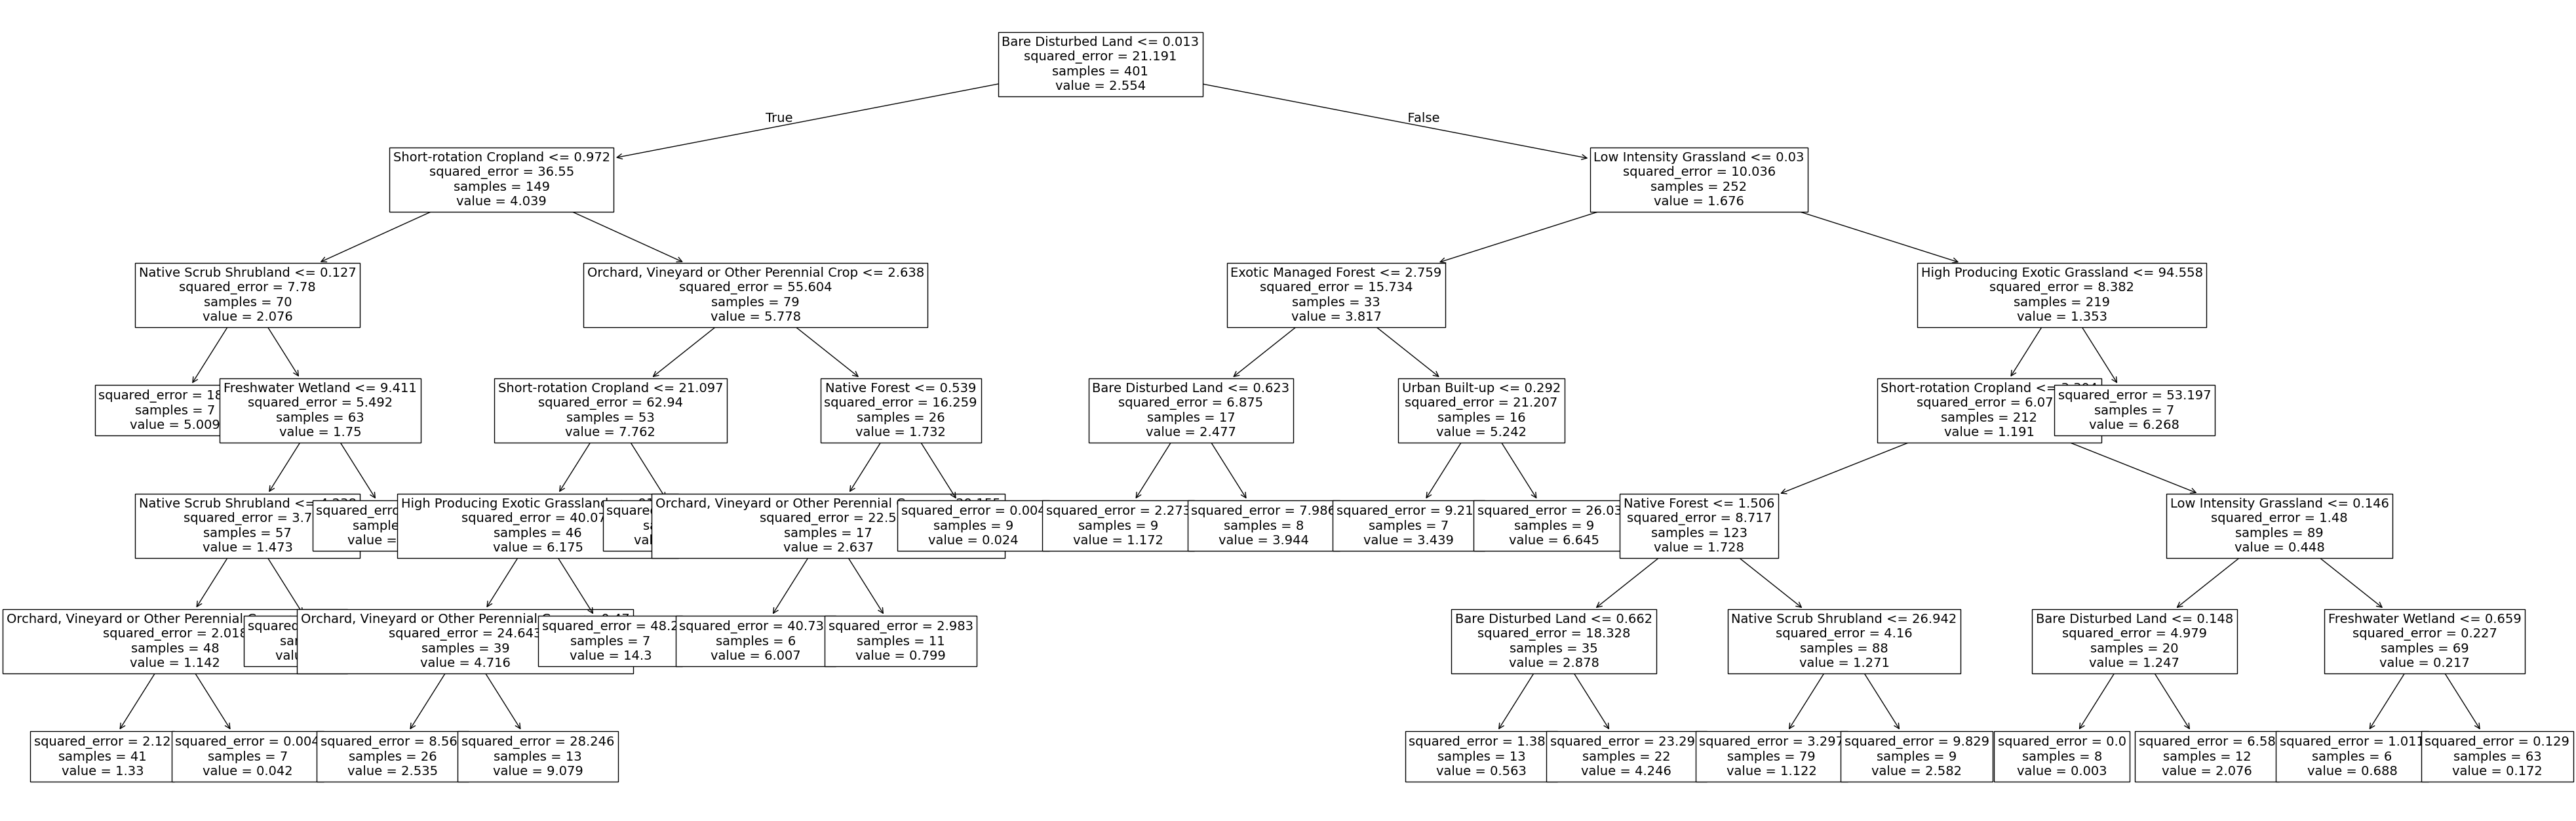

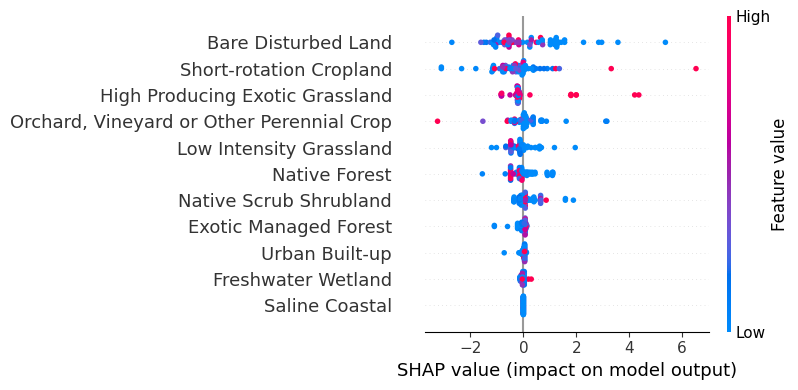

In [20]:
# Decision Tree attempt with grouped features
# --- Hyperparameter grid ---
param_dist = {
    'max_depth':         [None, 1, 2, 3, 4, 5, 6, 7, 8, 10],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf':  [1, 2, 4, 6, 8],
    'max_features':      ['sqrt', 'log2', 0.5, 1.0],
}

dt_search = RandomizedSearchCV(
    estimator=DecisionTreeRegressor(random_state=3),
    param_distributions=param_dist,
    n_iter=200,               # increase for a broader search
    scoring='r2',
    cv=5,                  
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
dt_search.fit(X_train_val, y_train_val.values.ravel())

print("Best params:", dt_search.best_params_)
print(f"Best val R²: {dt_search.best_score_:.4f}")

# --- Evaluate the best model on the held-out test set ---
best_dt = dt_search.best_estimator_
dt_r2  = best_dt.score(X_test, y_test)
dt_rmse = root_mean_squared_error(y_test, best_dt.predict(X_test))
dt_mae = mean_absolute_error(y_test, best_dt.predict(X_test))
print(f"Decision Tree Test R\u00B2:  {dt_r2:.4f}")
print(f"Decision Tree Test RMSE: {dt_rmse:.4f}")
print(f"Decision Tree Test MAE: {dt_mae:.4f}")
importances = pd.Series(best_dt.feature_importances_, index=X_train_val.columns).sort_values(ascending=False)
print('\nFeature Importance:')
print(importances)
plt.figure(figsize=(50, 16))
plot_tree(best_dt,feature_names = X_grouped.columns,fontsize = 14)
plt.show()

# Summary plot
explainer = shap.TreeExplainer(best_dt)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_size=(8,4))

The Decision Tree Regressor improves on LASSO across all metrics: $R^2$ rises to 0.218, RMSE falls to 3.24 mg/L, and MAE to 2.48 mg/L. The tree's ability to model non-linear threshold effects (e.g. nitrate only rising sharply above a certain percentage of cropland) gives it an edge over a strictly linear model.

Interpretability is reduced compared to LASSO. From the SHAP summary plot we can see that high percentages of Short-rotation Cropland and Exotic Grassland drive higher nitrate levels, and high percentages of Orchards reduce nitrate levels, but the complexity of the tree defeats the hope of interpretability, and there's no obvious way to quantify these effects as precisely as LASSO coefficients allow.

## Random Forest Regressor on raw data

In [21]:
# Random Forest attempt with grouped features
# --- Hyperparameter grid ---
param_dist = {
    'n_estimators':      [25, 50, 100, 200, 300, 500],
    'max_depth':         [1, 2, 3, 4, 5, 6, 10, 14, 18, 22],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5, 1.0],
    'bootstrap':         [True, False],
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=3),
    param_distributions=param_dist,
    n_iter=200,               # increase for a broader search
    scoring='r2',
    cv=5,                  
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
rf_search.fit(X_train_val, y_train_val.values.ravel())

print("Best params:", rf_search.best_params_)
print(f"Best val R\u00B2: {rf_search.best_score_:.4f}")

# --- Evaluate the best model on the held-out test set ---
best_rf = rf_search.best_estimator_
rf_r2  = best_rf.score(X_test, y_test)
rf_rmse = root_mean_squared_error(y_test, best_rf.predict(X_test))
rf_mae = mean_absolute_error(y_test, best_rf.predict(X_test))
print(f"Random Forest Test R\u00B2:  {rf_r2:.4f}")
print(f"Random Forest Test RMSE: {rf_rmse:.4f}")
print(f"Random Forest Test MAE: {rf_mae:.4f}")

# Get Feature Importance (The non-linear version of coefficients)
importances = pd.Series(best_rf.feature_importances_, index=X_train_val.columns).sort_values(ascending=False)
print("\nFeature Importance (Random Forest):")
print(importances)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best params: {'n_estimators': 50, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': True}
Best val R²: 0.2961
Random Forest Test R²:  0.2454
Random Forest Test RMSE: 3.1805
Random Forest Test MAE: 2.4136

Feature Importance (Random Forest):
Short-rotation Cropland                      0.184315
High Producing Exotic Grassland              0.149571
Orchard, Vineyard or Other Perennial Crop    0.124332
Freshwater Wetland                           0.094372
Native Forest                                0.084681
Exotic Managed Forest                        0.083082
Low Intensity Grassland                      0.074773
Native Scrub Shrubland                       0.067906
Urban Built-up                               0.058765
Bare Disturbed Land                          0.056231
Saline Coastal                               0.021971
dtype: float64


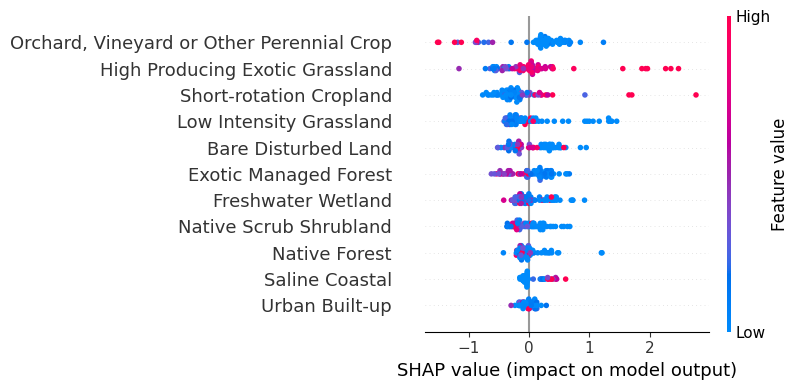

In [22]:
# Explain model predictions using SHAP
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, plot_size=(8,4))

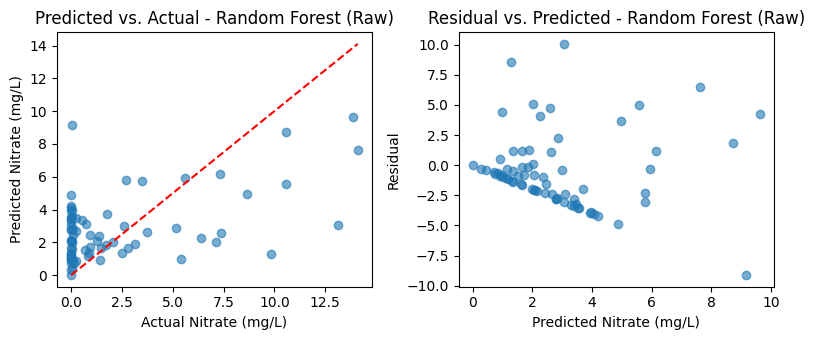

In [23]:
y_pred = best_rf.predict(X_test)
fig, [ax1, ax2] = plt.subplots(1,2,figsize=(8, 3.5))
ax1.scatter(y_test, y_pred, alpha=0.6)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax1.set_xlabel("Actual Nitrate (mg/L)")
ax1.set_ylabel("Predicted Nitrate (mg/L)")
ax1.set_title("Predicted vs. Actual - Random Forest (Raw)")
ax2.scatter(y_pred, y_test['State']-y_pred, alpha=0.6)
ax2.set_xlabel("Predicted Nitrate (mg/L)")
ax2.set_ylabel("Residual")
ax2.set_title("Residual vs. Predicted - Random Forest (Raw)")
plt.tight_layout()
plt.show()

The Random Forest Regressor achieves the best performance on raw data: $R^2$ = 0.245, RMSE = 3.18 mg/L, and MAE = 2.41 mg/L. The ensemble approach reduces the overfitting that can affect single decision trees, and the modest improvement over the single Decision Tree confirms that averaging across many trees adds value here.

Interpretability is further reduced relative to the Decision Tree as there's no single tree available to read. From the SHAP summary plot, Short-rotation Cropland and High Producing Exotic Grassland remain the strongest positive drivers of nitrate, with Orchards and Managed Forest acting as negative drivers. It is interesting to note that Managed Forest plays a more prominent role here than in the single Decision Tree, with higher percentages consistently associated with lower nitrate levels. This could suggest commercial forestry acts as a nitrogen sink, or given the compositional nature of the data forestry could be a consistent enough feature to indicate that other nitrogen sources aren't present.

The predicted vs. actual and residual plots show the model does better than LASSO but, like LASSO, struggles to predict the highest nitrate values, which remain somewhat underestimated. One advantage is that Random Forest only predicts positive values, unlike the unrealistic negative values that LASSO predicted in a small number of cases.


## LASSO on log transformed data

In [24]:
# Transform the target (Nitrate State)
y_train_log = np.log(y_train_val)
y_test_log = np.log(y_test)

# Fit the Lasso on the LOG scale
lasso_log = LassoCV(cv=5, random_state=42).fit(X_train_val, y_train_log.values.ravel())

# Evaluate on the Test Set (staying in log-space for R2 is statistically valid)
lasso_log_r2 = lasso_log.score(X_test, y_test_log)
print(f"Log-Scale Test R\u00B2: {lasso_log_r2:.4f}")
lasso_log_rmse = root_mean_squared_error(np.exp(y_test_log), np.exp(lasso_log.predict(X_test)))
print(f"Lasso Test RMSE (after inverse transform): {lasso_log_rmse:.4f}")
lasso_log_mae = mean_absolute_error(np.exp(y_test_log), np.exp(lasso_log.predict(X_test)))
print(f"Lasso Test MAE (after inverse transform): {lasso_log_mae:.4f}")

# To see the coefficients that drive the LOG change:
log_coefs = pd.Series(lasso_log.coef_, index=X_train_val.columns).sort_values(ascending=False)
print('\nCoefficients:')
print(log_coefs[log_coefs != 0])

Log-Scale Test R²: 0.0218
Lasso Test RMSE (after inverse transform): 4.1928
Lasso Test MAE (after inverse transform): 2.2604

Coefficients:
Native Forest                                0.026493
High Producing Exotic Grassland              0.024787
Orchard, Vineyard or Other Perennial Crop   -0.024507
dtype: float64


After the log transform LASSO almost entirely fails to explain the data, with $R^2$ plummeting to 0.022 and RMSE (inverse transformed to original scale to be comparable with the raw data results) increasing significantly to 4.19 mg/L. Fitting a linear model to log-nitrate is equivalent to fitting an exponential/multiplicative model in the original space, and these results suggest very little structure of that form is present. Not a surprising result, as we wouldn't expect the Nitrate combinations from various land uses to combine multiplicatively, so the log transform is not useful for a linear regression approach for this dataset.

## Decision Tree Regressor on log transformed data

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best params: {'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': 'log2', 'max_depth': 4}
Best val R²: 0.0798
Decision Tree Test R²:  0.0093
Decision Tree Test RMSE: 3.7376
Decision Tree Test MAE: 2.0914

Feature Importance:
Orchard, Vineyard or Other Perennial Crop    0.347237
Low Intensity Grassland                      0.283291
Native Forest                                0.178408
Freshwater Wetland                           0.064336
Short-rotation Cropland                      0.034135
Urban Built-up                               0.026920
Native Scrub Shrubland                       0.023927
High Producing Exotic Grassland              0.021559
Saline Coastal                               0.020187
Exotic Managed Forest                        0.000000
Bare Disturbed Land                          0.000000
dtype: float64


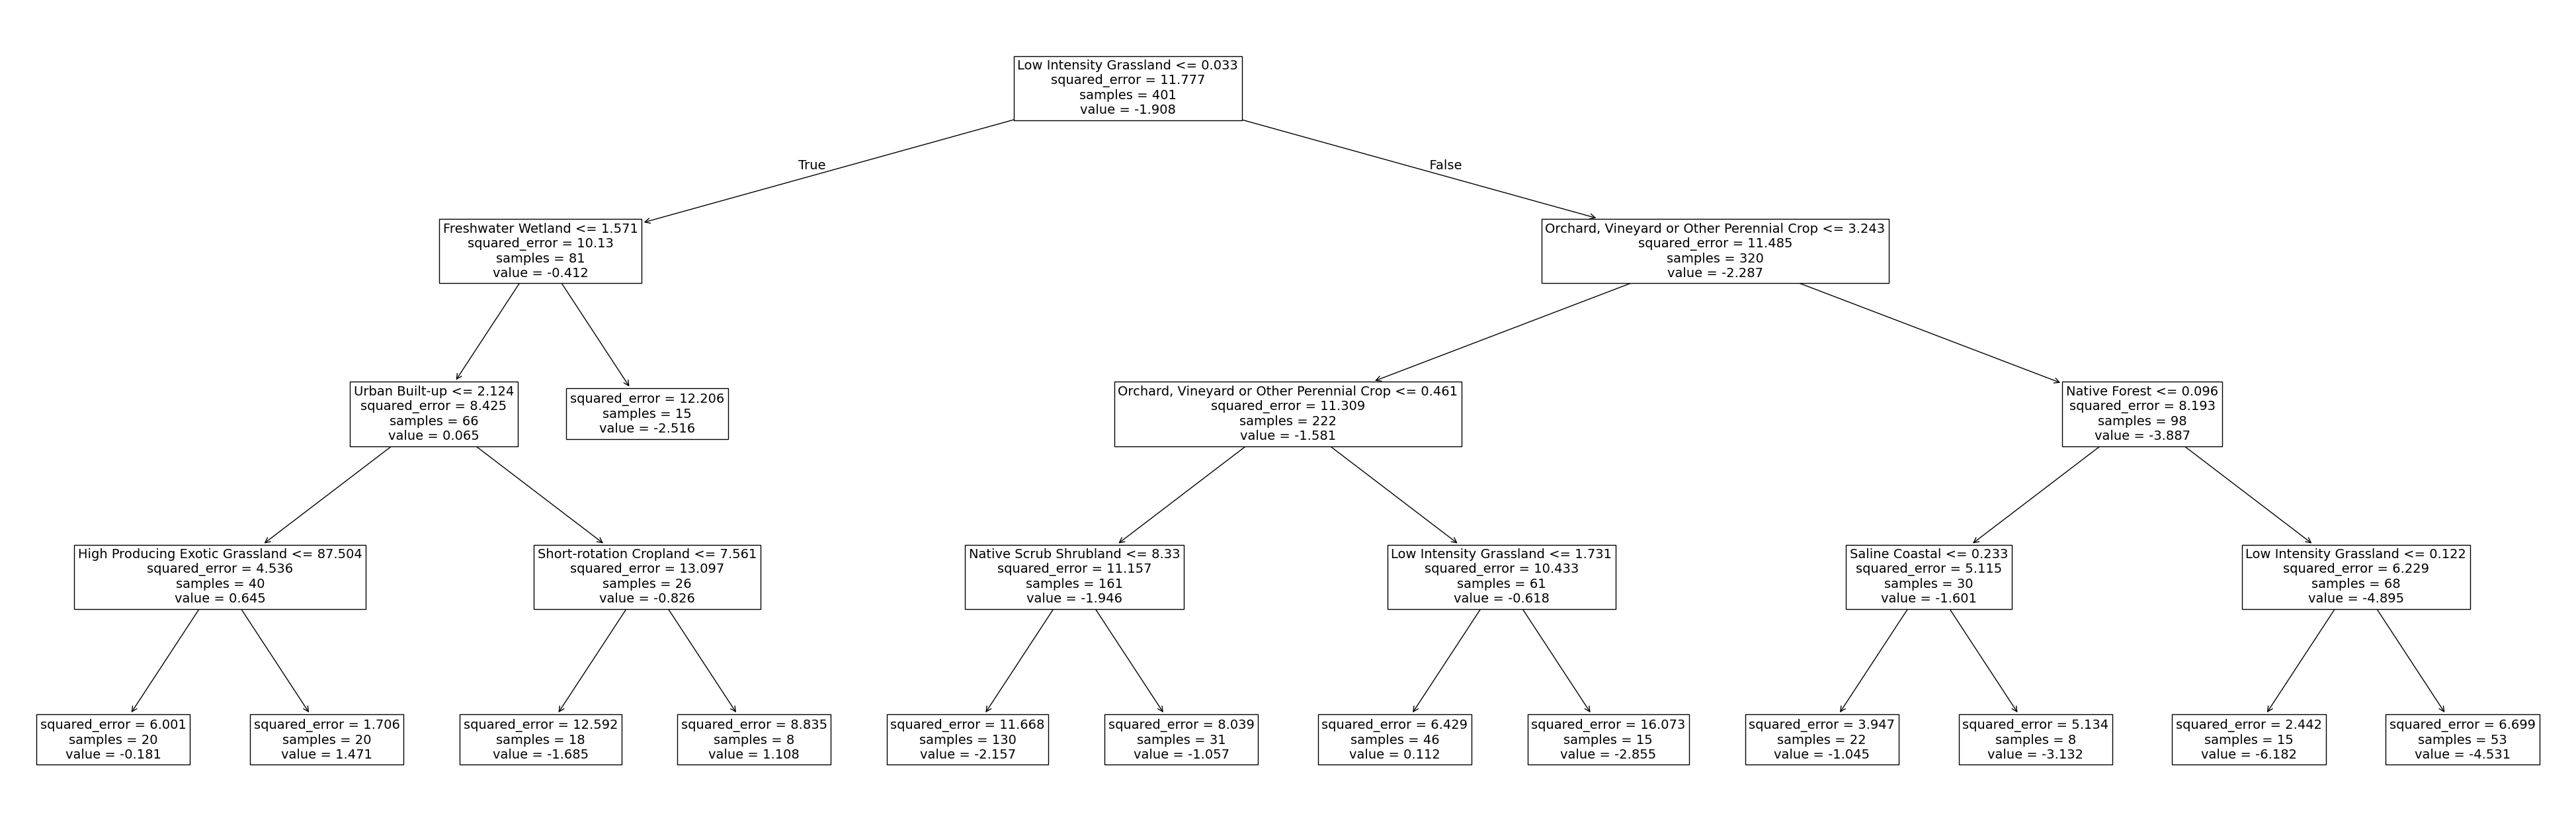

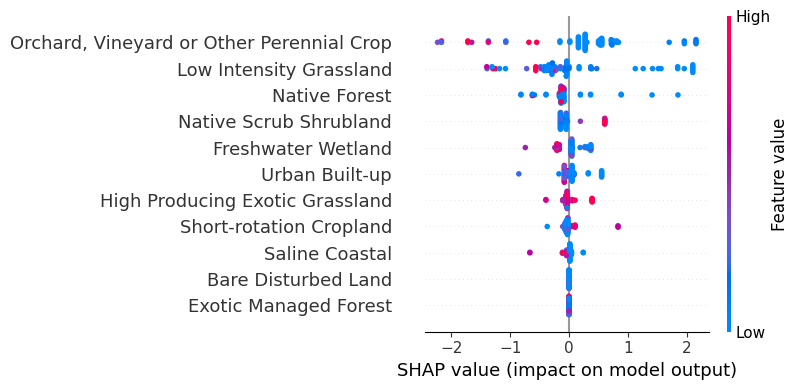

In [25]:
# --- Hyperparameter grid ---
param_dist = {
    'max_depth':         [None, 1, 2, 3, 4, 5, 6, 7, 8, 10],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf':  [1, 2, 4, 6, 8, 10],
    'max_features':      ['sqrt', 'log2', 0.5, 1.0],
}

dt_search = RandomizedSearchCV(
    estimator=DecisionTreeRegressor(random_state=3),
    param_distributions=param_dist,
    n_iter=200,               # increase for a broader search
    scoring='r2',
    cv=5,                  
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
dt_search.fit(X_train_val, y_train_log.values.ravel())

print("Best params:", dt_search.best_params_)
print(f"Best val R\u00B2: {dt_search.best_score_:.4f}")

# --- Evaluate the best model on the held-out test set ---
best_dt_log = dt_search.best_estimator_
dt_log_r2  = best_dt_log.score(X_test, y_test_log)
dt_log_rmse = root_mean_squared_error(np.exp(y_test_log), np.exp(best_dt_log.predict(X_test)))
dt_log_mae = mean_absolute_error(np.exp(y_test_log), np.exp(best_dt_log.predict(X_test)))
print(f"Decision Tree Test R\u00B2:  {dt_log_r2:.4f}")
print(f"Decision Tree Test RMSE: {dt_log_rmse:.4f}")
print(f"Decision Tree Test MAE: {dt_log_mae:.4f}")

importances = pd.Series(best_dt_log.feature_importances_, index=X_train_val.columns).sort_values(ascending=False)
print('\nFeature Importance:')
print(importances)
plt.figure(figsize=(50, 16))
plot_tree(best_dt_log,feature_names = X_grouped.columns,fontsize = 14)
plt.show()

# Explain model predictions using SHAP
explainer = shap.TreeExplainer(best_dt_log)
shap_values = explainer.shap_values(X_test)
# Summary plot
shap.summary_plot(shap_values, X_test, plot_size=(8,4))

The Decision Tree Regressor on log-transformed data similarly produces a near-zero $R^2$ of 0.009, confirming that working in log-space confers no benefit for tree-based splitting. RMSE inverse-transformed to original scale is 3.74 mg/L - lower than LASSO on log data, reflecting the tree's ability to handle non-linear structure, but MAE of 2.09 mg/L suggests it is focusing on the smaller nitrate values (which dominate after log transformation) at the expense of the larger values.

The SHAP summary shows the now expected effects of Exotic Grassland, Short-rotation Cropland and Orchards, though the effect of Exotic Grassland isn't as clear.

## Random Forest Regressor on log transformed data

In [26]:
# Random Forest attempt with grouped features & log

# --- Hyperparameter grid ---
param_dist = {
    'n_estimators':      [25, 50, 100, 200, 300, 500, 1000],
    'max_depth':         [1, 2, 3, 4, 5, 6, 10, 14, 18, 22],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5, 1.0],
    'bootstrap':         [True, False],
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=3),
    param_distributions=param_dist,
    n_iter=200,               # increase for a broader search
    scoring='r2',
    cv=5,                  
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
rf_search.fit(X_train_val, y_train_log.values.ravel())

print("Best params:", rf_search.best_params_)
print(f"Best val R\u00B2: {rf_search.best_score_:.4f}")

# --- Evaluate the best model on the held-out test set ---
best_rf_log = rf_search.best_estimator_
rf_log_r2  = best_rf_log.score(X_test, y_test_log)
rf_log_rmse = root_mean_squared_error(np.exp(y_test_log), np.exp(best_rf_log.predict(X_test)))
rf_log_mae = mean_absolute_error(np.exp(y_test_log), np.exp(best_rf_log.predict(X_test)))
print(f"Random Forest Test R\u00B2:  {rf_log_r2:.4f}")
print(f"Random Forest Test RMSE: {rf_log_rmse:.4f}")
print(f"Random Forest Test MAE: {rf_log_mae:.4f}")

# Get Feature Importance (The non-linear version of coefficients)
importances = pd.Series(best_rf_log.feature_importances_, index=X_train_val.columns).sort_values(ascending=False)
print("\nImportances (Random Forest):")
print(importances)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': True}
Best val R²: 0.2631
Random Forest Test R²:  0.2358
Random Forest Test RMSE: 3.7875
Random Forest Test MAE: 2.0346

Importances (Random Forest):
Orchard, Vineyard or Other Perennial Crop    0.131634
Freshwater Wetland                           0.124812
Short-rotation Cropland                      0.100120
High Producing Exotic Grassland              0.099456
Low Intensity Grassland                      0.098494
Native Forest                                0.097901
Urban Built-up                               0.089816
Native Scrub Shrubland                       0.080353
Exotic Managed Forest                        0.078288
Bare Disturbed Land                          0.068572
Saline Coastal                               0.030554
dtype: float64


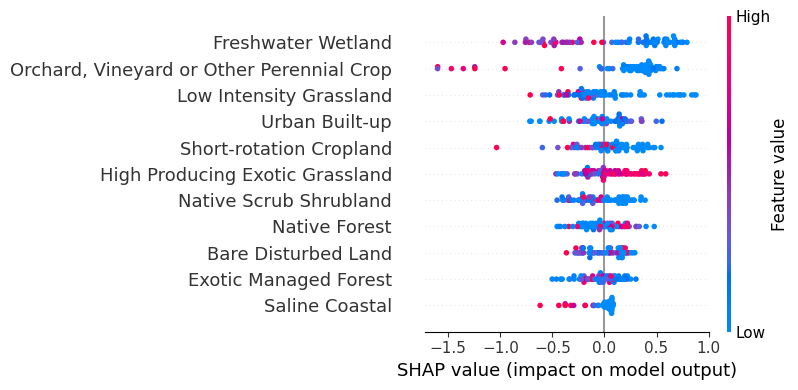

In [27]:
# Explain model predictions using SHAP
explainer = shap.TreeExplainer(best_rf_log)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, plot_size=(8,4))


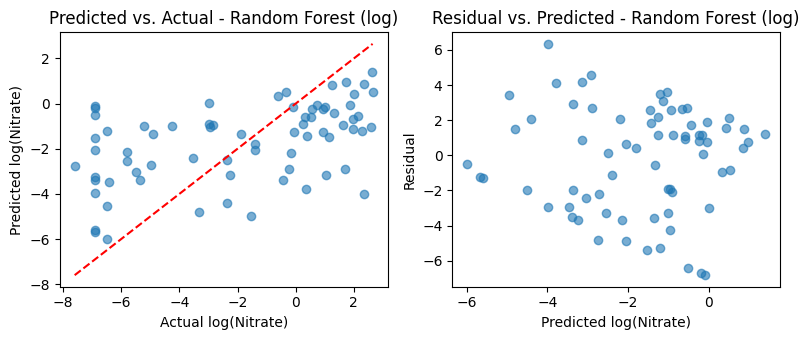

In [28]:
y_pred_log = best_rf_log.predict(X_test)
fig, [ax1, ax2] = plt.subplots(1,2,figsize=(8, 3.5))
ax1.scatter(y_test_log, y_pred_log, alpha=0.6)
ax1.plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], 'r--')
ax1.set_xlabel("Actual log(Nitrate)")
ax1.set_ylabel("Predicted log(Nitrate)")
ax1.set_title("Predicted vs. Actual - Random Forest (log)")
ax2.scatter(y_pred_log, y_test_log['State']-y_pred_log, alpha=0.6)
ax2.set_xlabel("Predicted log(Nitrate)")
ax2.set_ylabel("Residual")
ax2.set_title("Residual vs. Predicted - Random Forest (log)")
plt.tight_layout()
plt.show()

The surprise is that the Random Forest Regressor achieves an $R^2$ of 0.236, while not quite as good as with the raw data, still at a similar level. RMSE is significantly higher than models of the raw data though (3.79 mg/L), but not surprising as models will be driven more by changes of the small raw values after a log transform, reflected in the reduced MAE of 2.03 mg/L. This is the expected trade-off from a log transform, but not what we're looking for as the high nitrate observations are the most important environmentally. 

It's interesting to note that while Orchards and Exotic Grassland maintain similar impact in the SHAP summary, Short-rotation Cropland has flipped and become inverse. The reason for this is uncertain, but seems likely it's again due to the emphasis of smaller raw nitrate values as opposed to higher values.

# Summary and Conclusion

This project investigated whether nitrate levels in North Island groundwater wells could be predicted from land use patterns within a 5km radius, using data from LAWA and the LCDB v6.0 land cover database. After geospatial preprocessing, 472 well observations were available with 31 land use features expressed as percentage cover.

Given the compositional nature of the feature set - where all percentages sum to 100% - standard correlation-based dimension reduction was not appropriate, as features representing ecologically similar land uses tend to show inverse correlations due to this mathematical constraint rather than genuine dissimilarity. Instead, domain knowledge was applied to group 28 of the 31 features into 8 ecologically coherent groups, while retaining three commercial farming land uses (High Producing Exotic Grassland, Short-rotation Cropland, and Orchard/Vineyard) as standalone features due to their stronger individual correlations with nitrate levels. This produced an 11-feature design matrix.

Three regression models were evaluated - LassoCV, Decision Tree Regressor, and Random Forest Regressor - each on both raw and log-transformed target data, with hyperparameters tuned via RandomizedSearchCV with 5-fold cross-validation. Results are summarised in the table below:

In [50]:
summary = pd.DataFrame({
    'Model': ['LASSO', 'Decision Tree Regressor', 'Random Forest Regressor', 'LASSO', 'Decision Tree Regressor', 'Random Forest Regressor'],
    'Data': ['Raw' ,'Raw', 'Raw', 'Log', 'Log', 'Log'],
    'R\u00B2 score': [lasso_r2, dt_r2, rf_r2, lasso_log_r2, dt_log_r2, rf_log_r2],
    'RMSE': [lasso_rmse, dt_rmse, rf_rmse, lasso_log_rmse, dt_log_rmse, rf_log_rmse],
    'MAE': [lasso_mae, dt_mae, rf_mae, lasso_log_mae, dt_log_mae, rf_log_mae]
}).set_index('Model')

summary.round(3)

,Data,R² score,RMSE,MAE
Model,,,,
LASSO,Raw,0.187,3.300,2.560
Decision Tree Regressor,Raw,0.218,3.237,2.479
Random Forest Regressor,Raw,0.245,3.181,2.414
LASSO,Log,0.022,4.193,2.260
Decision Tree Regressor,Log,0.009,3.738,2.091
Random Forest Regressor,Log,0.236,3.788,2.035


From the table, models on the raw data generally outperform their log-transformed counterparts on $R^2$ and RMSE. The improved MAE metric for the log data reflects how the log transformed models focus on the smaller raw values, at the expense of greater error on the larger raw values. Given the importance of the higher values when it comes to environmental concerns, Random Forest Regressor on raw data is the best model, though a runner up could be LASSO on raw data if more detailed interpretability, i.e. the effect of the coefficients, was needed at the cost of predictive accuracy.

All results need to be treated with caution however, as even the best $R^2$ value is only 0.245, i.e. only 24.5% of the variance in nitrate levels is explained by land use alone. My reading on wells & bores suggested well depth was a key feature, as it is well established that nitrate is progressively filtered out as water descends through soil and rock, so deeper wells will inherently record lower concentrations regardless of surface land use. Deep wells are more likely to be used for irrigation too (because of their more consistent supply), which is more likely to be needed for Orchards & Vineyards - which could explain the inverse relationship of Nitrate levels to Orchard land use percentage, and why the Orchard feature has high importance in both raw and log data. A nice correlation vs. causation example, as the well might be drilled deep enough to have less nitrate because of its use in orchards, rather than orchards directly causing less nitrate.

In summary, land use type is a statistically significant predictor of groundwater nitrate levels in the North Island, with Short-rotation Cropland and High Producing Exotic Grassland as the strongest positive drivers. However, a more complete model is needed before these findings could be used to inform policy or regulation.

As part of seeking that more complete model, I investigate adding Well Depth as a feature in the following addendum, and find that adding well depth raised the $R^2$ from 0.136 to 0.335 on the 249 wells with depth data. This highlights the strong effect well depth can have on the model.

# Addendum: Inclusion of Well Depth

## Loading and Collation of Data

The most challenging part of adding in well depth as a feature was getting the data.
Hawke's Bay Regional Council data wouldn't download, but was accessible via GET request. Northland, Waikato, Bay of Plenty, Horizons and Greater Wellington Regional Council information was available via .csv file download, and unfortunately Auckland, Gisborne and Taranaki don't maintain publicly available records.
Once I had the information, it needed to be matched up with the LAWA wells - Horizons and Greater Wellington were straightforward as information in the .csv matched the LAWAWellName. However the data from the other three Councils didn't match by an identifier, so needed to be matched up based on location using geoPandas and cKDTree.

In [30]:
# Load Hawke's Bay Regional Council Well Data

BASE = "https://gis.hbrc.govt.nz/server/rest/services/ExternalServices/Reporting/MapServer/0"

# Download all records in one request (8764 < 10000 max)
r = requests.get(f"{BASE}/query", params={
    "where":             "1=1",
    "outFields":         "Easting,Northing,WellDepth",
    "returnGeometry":    "false",   # we have Easting/Northing as attributes
    "outSR":             "4326",
    "resultRecordCount": 10000,
    "f":                 "json",
}, timeout=60)

features = r.json()["features"]
hbrc_df = pd.DataFrame([f["attributes"] for f in features])
print(f"Downloaded {len(hbrc_df)} records")

# Drop rows missing coordinates or depth
hbrc_df = hbrc_df.dropna(subset=["Easting", "Northing", "WellDepth"])
print(f"After dropping nulls: {len(hbrc_df)} records")

hbrc_gdf = gpd.GeoDataFrame(
    hbrc_df[["WellDepth"]],
    geometry=gpd.points_from_xy(hbrc_df["Easting"], hbrc_df["Northing"]),
    crs="EPSG:2193"
)


Downloaded 8764 records
After dropping nulls: 7463 records


In [31]:
# ── 1. Load existing wells ───────────────────────────────────────────────
wells_gdf_2193 = wells_gdf.to_crs("EPSG:2193")

# ── 2. Horizons - direct name match on BoreID ─────────────────────────────────
horizons = pd.read_csv("horizons_bores.csv", usecols=["BoreID", "Depth"])
horizons = horizons.dropna(subset=["Depth"])
horizons = horizons.rename(columns={"BoreID": "LAWAWellName", "Depth": "WellDepth_m"})
horizons = horizons.drop_duplicates(subset="LAWAWellName")

# ── 3. Greater Wellington - direct name match on WELL_NO ─────────────────────
gwrc = pd.read_csv("gwrc_bores.csv", usecols=["WELL_NO", "DEPTH"])
gwrc = gwrc.dropna(subset=["DEPTH"])
gwrc = gwrc.rename(columns={"WELL_NO": "LAWAWellName", "DEPTH": "WellDepth_m"})
gwrc = gwrc.drop_duplicates(subset="LAWAWellName")

# ── 4. NRC - location match (X/Y are NZTM) ──────────────────────────
nrc_df = pd.read_csv("nrc_bores.csv", usecols=["X", "Y", "DepthOfBore"])
nrc_df = nrc_df.dropna(subset=["X", "Y", "DepthOfBore"])
nrc_gdf = gpd.GeoDataFrame(
    nrc_df[["DepthOfBore"]],
    geometry=gpd.points_from_xy(nrc_df["X"], nrc_df["Y"]),
    crs="EPSG:2193"
)

# ── 5. BoP - location match (X/Y are NZTM) ──────────────────────────
bop_df = pd.read_csv("bop_bores.csv", usecols=["X", "Y", "BoreDepth_m"])
bop_df = bop_df.dropna(subset=["X", "Y", "BoreDepth_m"])
bop_gdf = gpd.GeoDataFrame(
    bop_df[["BoreDepth_m"]],
    geometry=gpd.points_from_xy(bop_df["X"], bop_df["Y"]),
    crs="EPSG:2193"
)

# ── 6. Waikato - location match (has both NZTM and lat/lon, use NZTM directly)
waikato_df = pd.read_csv("waikato_bores.csv", usecols=["ACTUAL_EASTING", "ACTUAL_NORTHING", "ACTUAL_DEPTH_DRILLED"])
waikato_df = waikato_df.dropna(subset=["ACTUAL_EASTING", "ACTUAL_NORTHING", "ACTUAL_DEPTH_DRILLED"])
waikato_gdf = gpd.GeoDataFrame(
    waikato_df[["ACTUAL_DEPTH_DRILLED"]],
    geometry=gpd.points_from_xy(waikato_df["ACTUAL_EASTING"], waikato_df["ACTUAL_NORTHING"]),
    crs="EPSG:2193"
)

# ── 7. Nearest-neighbour spatial join helper ──────────────────────────────────
# Finds the nearest bore in bores_gdf to each well in wells_gdf based on their coordinates
def nearest_depth(wells_gdf, bores_gdf, depth_col, max_dist_m=300):
    w_coords = np.array([(g.x, g.y) for g in wells_gdf.geometry])
    b_coords = np.array([(g.x, g.y) for g in bores_gdf.geometry])
    tree = cKDTree(b_coords)
    dists, idxs = tree.query(w_coords, k=1)
    return [
        bores_gdf.iloc[idx][depth_col] if dist <= max_dist_m else np.nan
        for dist, idx in zip(dists, idxs)
    ]

# ── 8. Build depth series, layering sources by priority ──────────────────────
# Start with NaN for all wells
depth_series = pd.Series(np.nan, index=wells_gdf_2193.index, name="WellDepth_m")

# Spatial matches (lower confidence - apply first, overwritten by name matches)
nrc_depths = nearest_depth(wells_gdf_2193, nrc_gdf, "DepthOfBore")
waikato_depths = nearest_depth(wells_gdf_2193, waikato_gdf, "ACTUAL_DEPTH_DRILLED")
bop_depths = nearest_depth(wells_gdf_2193, bop_gdf, "BoreDepth_m")
hbrc_depths = nearest_depth(wells_gdf_2193, hbrc_gdf, "WellDepth")


depth_series = depth_series.fillna(pd.Series(waikato_depths, index=wells_gdf_2193.index))
depth_series = depth_series.fillna(pd.Series(nrc_depths, index=wells_gdf_2193.index))
depth_series = depth_series.fillna(pd.Series(bop_depths, index=wells_gdf_2193.index))
depth_series = depth_series.fillna(pd.Series(hbrc_depths, index=wells_gdf_2193.index))

# Name matches (higher confidence - apply last to overwrite any spatial match)
depth_series = depth_series.fillna(
    wells_gdf_2193.index.to_series().map(horizons.set_index("LAWAWellName")["WellDepth_m"])
)
depth_series = depth_series.fillna(
    wells_gdf_2193.index.to_series().map(gwrc.set_index("LAWAWellName")["WellDepth_m"])
)

wells_gdf_2193["WellDepth_m"] = depth_series

# ── 8. Coverage report ────────────────────────────────────────────────────────
n_total  = len(wells_gdf_2193)
n_found  = depth_series.notna().sum()
print(f"Depth coverage: {n_found}/{n_total} ({100*n_found/n_total:.1f}%)")
print(f"\nDepth distribution (where found):")
print(depth_series.dropna().describe())
print(f"\nMissing depth: {depth_series.isna().sum()} wells")

Depth coverage: 249/472 (52.8%)

Depth distribution (where found):
count    249.000000
mean      56.000161
std       68.429041
min        0.000000
25%       13.500000
50%       32.000000
75%       78.500000
max      460.200000
Name: WellDepth_m, dtype: float64

Missing depth: 223 wells


## Well Depth EDA

A scatterplot of Nitrate level vs. Well Depth for the wells with depth information shows a clear reduction in Nitrate level for deeper wells as expected, so we can expect Well Depth to play a part in the model.

<Axes: xlabel='WellDepth_m', ylabel='Nitrate level (mg/L)'>

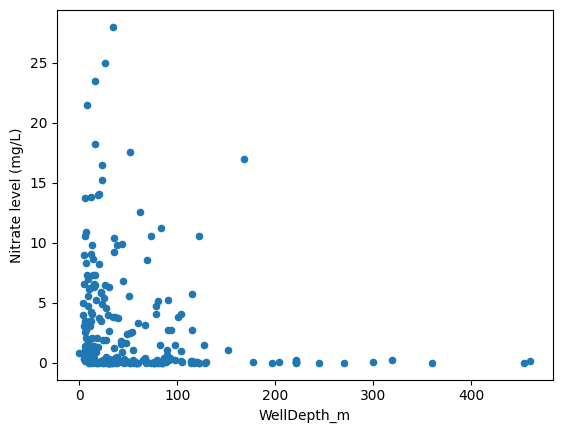

In [32]:
wells_gdf_2193[["LAWAWellName","WellDepth_m"]].join(y, on='LAWAWellName').dropna().plot.scatter(x="WellDepth_m", y="State", ylabel="Nitrate level (mg/L)")

In [33]:
X_with_depth = wells_gdf_2193.join(X_grouped, on='LAWAWellName').dropna(subset=["WellDepth_m"])
X_with_depth = X_with_depth.set_index('LAWAWellName')[['WellDepth_m',
       'High Producing Exotic Grassland', 'Short-rotation Cropland',
       'Orchard, Vineyard or Other Perennial Crop', 'Low Intensity Grassland',
       'Native Scrub Shrubland', 'Native Forest', 'Exotic Managed Forest',
       'Urban Built-up', 'Freshwater Wetland', 'Saline Coastal',
       'Bare Disturbed Land']]
print(X_with_depth.shape)          # should be (249, 12)
print(X_with_depth["WellDepth_m"].describe())  # sanity check

(249, 12)
count    249.000000
mean      56.000161
std       68.429041
min        0.000000
25%       13.500000
50%       32.000000
75%       78.500000
max      460.200000
Name: WellDepth_m, dtype: float64


## Modelling with and without Well Depth

I fit the 249 data points with well depth information first using Random Forest using the same hyperparameter search but with well depth included as a feature, then again on the same data points but with well depth removed to obtain a comparison in model performance.

In [34]:
# Drop rows where depth is missing
mask = X_with_depth.notna()
X_depth = X_with_depth.copy()
y_depth = y.loc[X_depth.index].copy()

print(f"Fitting on {len(X_depth)} wells with {X_depth.shape[1]} features")

# Stratified split (same approach as before)
bins_depth = pd.qcut(y_depth["State"], q=10, duplicates="drop")

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_depth, y_depth,
    test_size=0.15,
    random_state=3,
    stratify=bins_depth
)

# Refit Random Forest with same hyperparameter search
param_dist = {
    'n_estimators':      [25, 50, 100, 200, 300, 500],
    'max_depth':         [1, 2, 3, 4, 5, 6, 10, 14, 18],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5, 1.0],
    'bootstrap':         [True, False],
}

rf_depth_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=3),
    param_distributions=param_dist,
    n_iter=200,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
rf_depth_search.fit(X_train_d, y_train_d.values.ravel())

best_rf_depth = rf_depth_search.best_estimator_
rf_depth_r2  = best_rf_depth.score(X_test_d, y_test_d)
rf_depth_rmse = root_mean_squared_error(y_test_d, best_rf_depth.predict(X_test_d))
rf_depth_mae = mean_absolute_error(y_test_d, best_rf_depth.predict(X_test_d))

print(f"\nRandom Forest WITH depth (n=249):")
print(f"  R²:   {rf_depth_r2:.4f}")
print(f"  RMSE: {rf_depth_rmse:.4f}")
print(f"  MAE:  {rf_depth_mae:.4f}")
print(rf_depth_search.best_params_, '\n')

# For fair comparison - also refit WITHOUT depth on the same n=249 subset
rf_nodepth_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=3),
    param_distributions=param_dist,
    n_iter=200,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
rf_nodepth_search.fit(X_train_d[X_grouped.columns], y_train_d.values.ravel())

best_rf_nodepth = rf_nodepth_search.best_estimator_
rf_nodepth_r2 = best_rf_nodepth.score(X_test_d[X_grouped.columns], y_test_d)
rf_nodepth_rmse = root_mean_squared_error(y_test_d, best_rf_nodepth.predict(X_test_d[X_grouped.columns]))
rf_nodepth_mae = mean_absolute_error(y_test_d, best_rf_nodepth.predict(X_test_d[X_grouped.columns]))

print(f"\nRandom Forest WITHOUT depth (same n=249 subset):")
print(f"  R²:   {rf_nodepth_r2:.4f}")
print(f"  RMSE: {rf_nodepth_rmse:.4f}")
print(f"  MAE:  {rf_nodepth_mae:.4f}")
print(rf_nodepth_search.best_params_)

Fitting on 249 wells with 12 features
Fitting 5 folds for each of 200 candidates, totalling 1000 fits

Random Forest WITH depth (n=249):
  R²:   0.3353
  RMSE: 2.9363
  MAE:  2.1563
{'n_estimators': 100, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 3, 'bootstrap': True} 

Fitting 5 folds for each of 200 candidates, totalling 1000 fits

Random Forest WITHOUT depth (same n=249 subset):
  R²:   0.1364
  RMSE: 3.3468
  MAE:  2.6830
{'n_estimators': 500, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 1, 'bootstrap': True}


In [41]:
importances_depth = pd.Series(
    best_rf_depth.feature_importances_,
    index=X_depth.columns
).sort_values(ascending=False)
print("Feature importances with depth:")
print(importances_depth)

Feature importances with depth:
Exotic Managed Forest                        0.157994
Short-rotation Cropland                      0.147518
Low Intensity Grassland                      0.127671
WellDepth_m                                  0.084337
Native Forest                                0.078949
High Producing Exotic Grassland              0.076138
Bare Disturbed Land                          0.073519
Orchard, Vineyard or Other Perennial Crop    0.066360
Native Scrub Shrubland                       0.063093
Urban Built-up                               0.048238
Freshwater Wetland                           0.043240
Saline Coastal                               0.032942
dtype: float64


In [42]:
importances_nodepth = pd.Series(
    best_rf_nodepth.feature_importances_,
    index=X_grouped.columns
).sort_values(ascending=False)
print("Feature importances without depth:")
print(importances_nodepth)

Feature importances without depth:
Low Intensity Grassland                      0.176
Exotic Managed Forest                        0.176
High Producing Exotic Grassland              0.156
Bare Disturbed Land                          0.144
Short-rotation Cropland                      0.144
Orchard, Vineyard or Other Perennial Crop    0.074
Native Scrub Shrubland                       0.046
Freshwater Wetland                           0.042
Urban Built-up                               0.026
Native Forest                                0.010
Saline Coastal                               0.006
dtype: float64


SHAP summary for Random Forest with depth


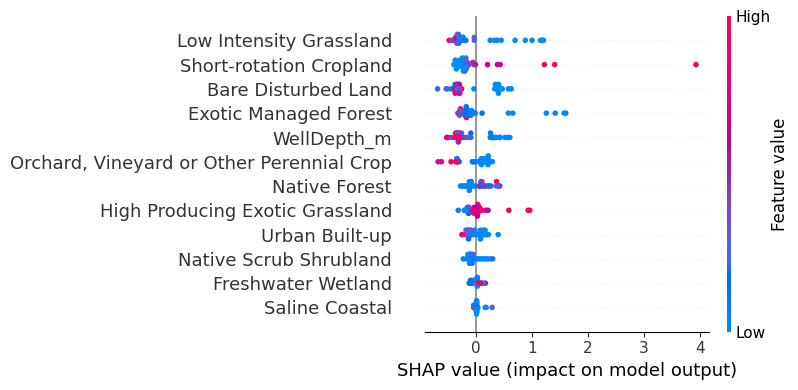

In [47]:
print("SHAP summary for Random Forest with depth")
explainer = shap.TreeExplainer(best_rf_depth)
shap_values = explainer.shap_values(X_test_d)
shap.summary_plot(shap_values, X_test_d, plot_size=(8,4))

SHAP summary for Random Forest without depth


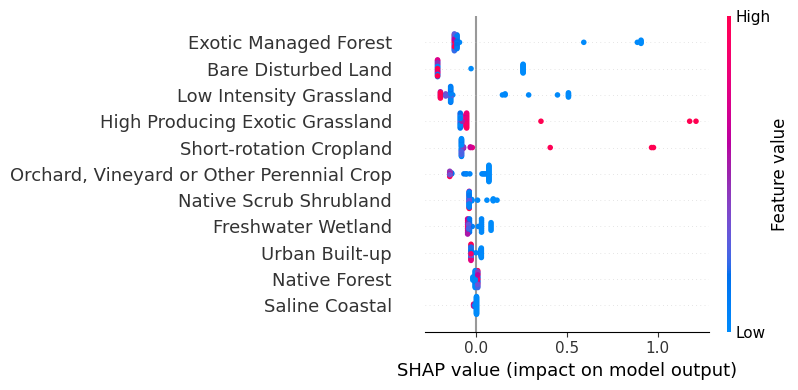

In [46]:
print("SHAP summary for Random Forest without depth")
explainer = shap.TreeExplainer(best_rf_nodepth)
shap_values = explainer.shap_values(X_test_d[X_grouped.columns])
shap.summary_plot(shap_values, X_test_d[X_grouped.columns], plot_size=(8,4))

Predict vs. Actual and Residual vs. Predicted plots for Random Forest with depth


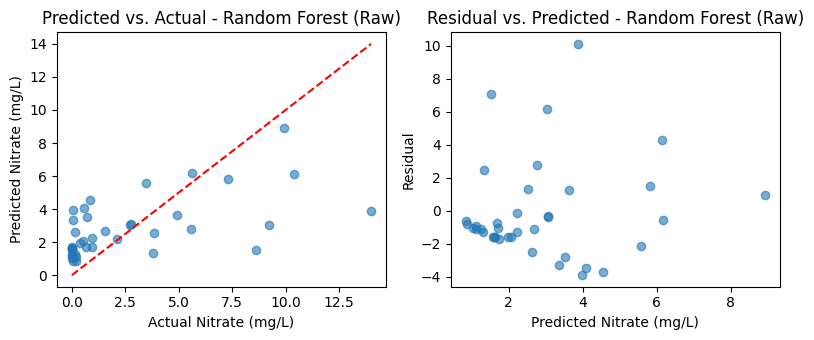

In [45]:
print("Predict vs. Actual and Residual vs. Predicted plots for Random Forest with depth")
y_pred = best_rf_depth.predict(X_test_d)
fig, [ax1, ax2] = plt.subplots(1,2,figsize=(8, 3.5))
ax1.scatter(y_test_d, y_pred, alpha=0.6)
ax1.plot([y_test_d.min(), y_test_d.max()], [y_test_d.min(), y_test_d.max()], 'r--')
ax1.set_xlabel("Actual Nitrate (mg/L)")
ax1.set_ylabel("Predicted Nitrate (mg/L)")
ax1.set_title("Predicted vs. Actual - Random Forest (Raw)")
ax2.scatter(y_pred, y_test_d['State']-y_pred, alpha=0.6)
ax2.set_xlabel("Predicted Nitrate (mg/L)")
ax2.set_ylabel("Residual")
ax2.set_title("Residual vs. Predicted - Random Forest (Raw)")
plt.tight_layout()
plt.show()

## Well Depth Summary & Conclusions

The EDA scatterplot confirms the expected negative relationship between well depth and nitrate level: as depth increases, nitrate concentrations fall, consistent with the known filtering effect of soil and rock as groundwater descends. This relationship motivates the inclusion of depth as a feature.

Fitting the Random Forest Regressor on the 249 wells with depth information produces a clear result:

In [51]:
depth_comparison = pd.DataFrame({
    'Model': ['Random Forest with Well Depth', 'Random Forest without Well Depth'],
    'n': [249, 249],
    'R²': [rf_depth_r2, rf_nodepth_r2],
    'RMSE': [rf_depth_rmse, rf_nodepth_rmse],
    'MAE': [rf_depth_mae, rf_nodepth_mae],
}).set_index('Model')

depth_comparison.round(3)

,n,R²,RMSE,MAE
Model,,,,
Random Forest with Well Depth,249,0.335,2.936,2.156
Random Forest without Well Depth,249,0.136,3.347,2.683



Including well depth increases $R^2$ from 0.136 to 0.335, more than doubling the explained variance, and reduces both RMSE and MAE substantially.

Note that the no-depth model fitted on the 249-well subset ($R^2$ = 0.136) performs worse than the same model fitted on the full 472-well dataset ($R^2$ = 0.245). This is because the 249 wells with depth data are not a random subset - they are drawn from only six of the nine regional councils, and the wells missing depth information (from Auckland, Taranaki, and Gisborne) may include a different mix of shallow and deep bores. This selection bias should be kept in mind when interpreting the improvement due to depth.

The SHAP summary for the depth-inclusive model ranks well depth fifth, and showing the expected effect of larger well depth reducing nitrate levels. Looking at the SHAP summaries, in short, the summary for the random forest with well depth makes more sense. High Performance Grassland and Short Rotation Cropland are more obviously positive drivers of nitrate, and this is particularly emphasised for Short Rotation Cropland. It's also interesting to see Native Forest emerges as a small positive driver of nitrate levels too.

The Predicted vs. Actual plot is notable because what was a vertical line of points at 0 actual nitrate for both LASSO and Random Forest without depth, is now a much better fitting cluster.

**Conclusions from the Well Depth Addendum:**

Well depth is a critical predictor of groundwater nitrate levels and should be included in any operational model - the improvement in $R^2$ from adding a single depth feature exceeds the improvement achieved by moving from LASSO to Random Forest on the land-use-only data. Reassuringly, the land use relationships identified in the main analysis, particularly the importance of Short-rotation Cropland and High Producing Exotic Grassland, hold up after controlling for depth, providing stronger evidence that these are genuine drivers rather than proxies for well depth. The dataset remains incomplete however, as depth records could not be obtained for Auckland, Taranaki, and Gisborne wells, and expanding depth coverage to the full 472-well dataset would be a natural next step. Even with depth included, R² = 0.335 leaves substantial unexplained variance, which is unsurprising given that Short-rotation Cropland alone encompasses a wide variety of crops with very different fertiliser regimes, and factors such as rainfall and soil type are absent from the model entirely.